<a href="https://colab.research.google.com/github/rduvvada/my-first-repo/blob/main/Capstone_Project_All_Modeules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Module:1**

In [ ]:
!pip -q install requests beautifulsoup4 pandas

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import sqlite3
import os
import re
from pathlib import Path

BASE_URL = "https://books.toscrape.com/"
FIXED_GBP_TO_INR = 105.50

OUTPUT_DIR = Path("/content/data_pipeline")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DB_PATH = OUTPUT_DIR / "books_catalog.db"

In [ ]:
def scrape_books(max_pages=5):
    """
    Scrape the first max_pages catalogue pages from Books to Scrape.
    """

    session = requests.Session()
    session.headers.update({
        "User-Agent": "Mozilla/5.0 (compatible; DataPipeline/1.0)"
    })

    records = []

    for page_number in range(1, max_pages + 1):

        if page_number == 1:
            url = BASE_URL + "index.html"
        else:
            url = BASE_URL + f"catalogue/page-{page_number}.html"

        print(f"Scraping page {page_number}: {url}")

        response = session.get(url, timeout=30)
        response.raise_for_status()

        soup = BeautifulSoup(response.text, "html.parser")

        books = soup.select("article.product_pod")

        if not books:
            print(f"No books found on page {page_number}")
            continue

        for book in books:

            title_tag = book.select_one("h3 a")
            price_tag = book.select_one(".price_color")
            rating_tag = book.select_one("p.star-rating")
            availability_tag = book.select_one(".availability")

            title = (
                title_tag.get("title", "").strip()
                if title_tag else None
            )

            price = (
                price_tag.get_text(strip=True)
                if price_tag else None
            )

            rating = None
            if rating_tag:
                rating_classes = rating_tag.get("class", [])
                rating_words = {
                    "One": 1,
                    "Two": 2,
                    "Three": 3,
                    "Four": 4,
                    "Five": 5
                }

                for word, value in rating_words.items():
                    if word in rating_classes:
                        rating = word
                        break

            availability = (
                availability_tag.get_text(" ", strip=True)
                if availability_tag else None
            )


            category = None

            if title_tag and title_tag.get("href"):
                book_url = requests.compat.urljoin(
                    url,
                    title_tag["href"]
                )

                try:
                    detail_response = session.get(
                        book_url,
                        timeout=30
                    )
                    detail_response.raise_for_status()

                    detail_soup = BeautifulSoup(
                        detail_response.text,
                        "html.parser"
                    )

                    breadcrumb = detail_soup.select(
                        "ul.breadcrumb li"
                    )

                    if len(breadcrumb) >= 3:
                        category = breadcrumb[2].get_text(
                            strip=True
                        )

                except requests.RequestException as exc:
                    print(
                        f"Category request failed for {title}: {exc}"
                    )

            records.append({
                "title": title,
                "price": price,
                "star_rating": rating,
                "availability": availability,
                "category": category
            })

    return pd.DataFrame(records)


raw_df = scrape_books(max_pages=5)

print("\nRaw records:", len(raw_df))
raw_df.head()

Scraping page 1: https://books.toscrape.com/index.html
Scraping page 2: https://books.toscrape.com/catalogue/page-2.html
Scraping page 3: https://books.toscrape.com/catalogue/page-3.html
Scraping page 4: https://books.toscrape.com/catalogue/page-4.html
Scraping page 5: https://books.toscrape.com/catalogue/page-5.html

Raw records: 100


,title,price,star_rating,availability,category
0,A Light in the Attic,Â£51.77,Three,In stock,Poetry
1,Tipping the Velvet,Â£53.74,One,In stock,Historical Fiction
2,Soumission,Â£50.10,One,In stock,Fiction
3,Sharp Objects,Â£47.82,Four,In stock,Mystery
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock,History


In [ ]:
def clean_price(value):
    """
    Convert Â£51.77 -> 51.77.
    """
    if pd.isna(value):
        return None

    try:
        # Updated to handle both '£' and 'Â£'
        cleaned = str(value).replace("£", "").replace("Â", "").strip()
        return float(cleaned)
    except (ValueError, TypeError):
        return None


def clean_rating(value):
    """
    Convert One/Two/Three/Four/Five -> 1-5.
    """
    mapping = {
        "One": 1,
        "Two": 2,
        "Three": 3,
        "Four": 4,
        "Five": 5
    }

    if pd.isna(value):
        return None

    return mapping.get(str(value).strip())


def clean_stock(value):
    """
    Convert availability text to boolean.
    """
    if pd.isna(value):
        return None

    text = str(value).lower().strip()

    if "in stock" in text:
        return True

    if "out of stock" in text:
        return False

    return None


df = raw_df.copy()

df["price_gbp"] = df["price"].apply(clean_price)
df["rating"] = df["star_rating"].apply(clean_rating)
df["in_stock"] = df["availability"].apply(clean_stock)

# Numeric-field median imputation
for column in ["price_gbp", "rating"]:
    if df[column].isna().any():
        median_value = df[column].median()
        df[column] = df[column].fillna(median_value)

# Drop rows where essential categorical/boolean information
# cannot be safely recovered.
df = df.dropna(
    subset=["title", "category", "in_stock"]
).copy()

df["rating"] = df["rating"].astype(int)
df["in_stock"] = df["in_stock"].astype(bool)

# Fixed project-defined conversion
df["price_inr"] = (
    df["price_gbp"] * FIXED_GBP_TO_INR
).round(2)

# Keep only required cleaned columns
df = df[
    [
        "title",
        "price_gbp",
        "price_inr",
        "rating",
        "in_stock",
        "category"
    ]
].reset_index(drop=True)

print("Cleaned rows:", len(df))
print("Categories:", df["category"].nunique())

df.head()

Cleaned rows: 100
Categories: 29


,title,price_gbp,price_inr,rating,in_stock,category
0,A Light in the Attic,51.77,5461.74,3,True,Poetry
1,Tipping the Velvet,53.74,5669.57,1,True,Historical Fiction
2,Soumission,50.10,5285.55,1,True,Fiction
3,Sharp Objects,47.82,5045.01,4,True,Mystery
4,Sapiens: A Brief History of Humankind,54.23,5721.26,5,True,History


In [ ]:
assert len(df) >= 60, (
    f"Expected at least 60 books, found {len(df)}"
)

assert df["category"].nunique() >= 3, (
    f"Expected at least 3 categories, "
    f"found {df['category'].nunique()}"
)

assert df["rating"].between(1, 5).all()

assert df["price_gbp"].notna().all()
assert df["price_inr"].notna().all()

assert (
    (df["price_inr"] -
     df["price_gbp"] * FIXED_GBP_TO_INR)
    .abs() < 0.01
).all()

print("All data validation checks passed.")
print(f"Books: {len(df)}")
print(f"Categories: {df['category'].nunique()}")
print(f"Conversion rate: 1 GBP = {FIXED_GBP_TO_INR} INR")

All data validation checks passed.
Books: 100
Categories: 29
Conversion rate: 1 GBP = 105.5 INR


In [ ]:
if DB_PATH.exists():
    DB_PATH.unlink()

conn = sqlite3.connect(DB_PATH)

conn.execute("PRAGMA foreign_keys = ON")

cursor = conn.cursor()

cursor.execute("""
CREATE TABLE categories (
    category_id INTEGER PRIMARY KEY AUTOINCREMENT,
    category_name TEXT NOT NULL UNIQUE
)
""")

cursor.execute("""
CREATE TABLE books (
    book_id INTEGER PRIMARY KEY AUTOINCREMENT,
    title TEXT NOT NULL,
    price_gbp REAL NOT NULL,
    price_inr REAL NOT NULL,
    rating INTEGER NOT NULL,
    in_stock INTEGER NOT NULL,
    category_id INTEGER NOT NULL,
    FOREIGN KEY (category_id)
        REFERENCES categories(category_id)
)
""")

# Insert categories
categories = sorted(df["category"].unique())

cursor.executemany(
    """
    INSERT INTO categories (category_name)
    VALUES (?)
    """,
    [(category,) for category in categories]
)

# Get category IDs
category_map = {
    name: category_id
    for category_id, name
    in conn.execute(
        "SELECT category_id, category_name FROM categories"
    ).fetchall()
}

# Insert books
book_records = []

for _, row in df.iterrows():
    book_records.append((
        row["title"],
        float(row["price_gbp"]),
        float(row["price_inr"]),
        int(row["rating"]),
        int(row["in_stock"]),
        category_map[row["category"]]
    ))

cursor.executemany(
    """
    INSERT INTO books (
        title,
        price_gbp,
        price_inr,
        rating,
        in_stock,
        category_id
    )
    VALUES (?, ?, ?, ?, ?, ?)
    """,
    book_records
)

conn.commit()

print("SQLite database created:")
print(DB_PATH)

SQLite database created:
/content/data_pipeline/books_catalog.db


In [ ]:
queries = {}

queries["Q1_SELECT_WHERE"] = """
SELECT title, price_gbp, rating
FROM books
WHERE rating >= 4
"""

queries["Q2_ORDER_LIMIT"] = """
SELECT title, price_gbp
FROM books
ORDER BY price_gbp DESC
LIMIT 10
"""

queries["Q3_DISTINCT"] = """
SELECT DISTINCT rating
FROM books
ORDER BY rating
"""

queries["Q4_BETWEEN"] = """
SELECT title, price_gbp
FROM books
WHERE price_gbp BETWEEN 20 AND 40
ORDER BY price_gbp
"""

queries["Q5_IN"] = """
SELECT title, rating, in_stock
FROM books
WHERE rating IN (4, 5)
ORDER BY rating DESC, title
LIMIT 15
"""

queries["Q6_JOIN"] = """
SELECT
    c.category_name,
    b.title,
    b.rating,
    b.price_gbp,
    b.price_inr,
    b.in_stock
FROM books b
JOIN categories c
    ON b.category_id = c.category_id
ORDER BY
    c.category_name,
    b.rating DESC,
    b.title
LIMIT 30
"""

sql_outputs = {}

for name, query in queries.items():

    print("=" * 80)
    print(name)
    print(query.strip())
    print("-" * 80)

    result = pd.read_sql(query, conn)

    sql_outputs[name] = result

    display(result)

Q1_SELECT_WHERE
SELECT title, price_gbp, rating
FROM books
WHERE rating >= 4
--------------------------------------------------------------------------------


,title,price_gbp,rating
0,Sharp Objects,47.82,4
1,Sapiens: A Brief History of Humankind,54.23,5
2,The Dirty Little Secrets of Getting Your Dream...,33.34,4
3,The Boys in the Boat: Nine Americans and Their...,22.60,4
4,Shakespeare's Sonnets,20.66,4
5,Set Me Free,17.46,5
6,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29,5
7,Rip it Up and Start Again,35.02,5
8,Chase Me (Paris Nights #2),25.27,5
9,Black Dust,34.53,5


Q2_ORDER_LIMIT
SELECT title, price_gbp
FROM books
ORDER BY price_gbp DESC
LIMIT 10
--------------------------------------------------------------------------------


,title,price_gbp
0,The Death of Humanity: and the Case for Life,58.11
1,Slow States of Collapse: Poems,57.31
2,Our Band Could Be Your Life: Scenes from the A...,57.25
3,The Past Never Ends,56.50
4,The Pioneer Woman Cooks: Dinnertime: Comfort C...,56.41
5,Masks and Shadows,56.40
6,The Secret of Dreadwillow Carse,56.13
7,The Electric Pencil: Drawings from Inside Stat...,56.06
8,Birdsong: A Story in Pictures,54.64
9,Sapiens: A Brief History of Humankind,54.23


Q3_DISTINCT
SELECT DISTINCT rating
FROM books
ORDER BY rating
--------------------------------------------------------------------------------


...

,title,price_gbp
0,The Inefficiency Assassin: Time Management Tac...,20.59
1,Shakespeare's Sonnets,20.66
2,In the Country We Love: My Family Divided,22.00
3,America's Cradle of Quarterbacks: Western Penn...,22.50
4,The Boys in the Boat: Nine Americans and Their...,22.60
5,The Requiem Red,22.65
6,#HigherSelfie: Wake Up Your Life. Free Your So...,23.11
7,The Elephant Tree,23.82
8,Olio,23.88
9,The Mindfulness and Acceptance Workbook for An...,23.89


Q5_IN
SELECT title, rating, in_stock
FROM books
WHERE rating IN (4, 5)
ORDER BY rating DESC, title
LIMIT 15
--------------------------------------------------------------------------------


,title,rating,in_stock
0,#HigherSelfie: Wake Up Your Life. Free Your So...,5,1
1,Black Dust,5,1
2,Chase Me (Paris Nights #2),5,1
3,Join,5,1
4,Princess Between Worlds (Wide-Awake Princess #5),5,1
5,"Princess Jellyfish 2-in-1 Omnibus, Vol. 01 (Pr...",5,1
6,Private Paris (Private #10),5,1
7,Rip it Up and Start Again,5,1
8,Sapiens: A Brief History of Humankind,5,1
9,Scott Pilgrim's Precious Little Life (Scott Pi...,5,1


Q6_JOIN
SELECT
    c.category_name,
    b.title,
    b.rating,
    b.price_gbp,
    b.price_inr,
    b.in_stock
FROM books b
JOIN categories c
    ON b.category_id = c.category_id
ORDER BY
    c.category_name,
    b.rating DESC,
    b.title
LIMIT 30
--------------------------------------------------------------------------------


,category_name,title,rating,price_gbp,price_inr,in_stock
0,Add a comment,The Mindfulness and Acceptance Workbook for An...,4,23.89,2520.40,1
1,Add a comment,On a Midnight Clear,3,14.07,1484.38,1
2,Add a comment,The Art Forger,3,40.76,4300.18,1
3,Add a comment,Judo: Seven Steps to Black Belt (an Introducto...,2,53.90,5686.45,1
4,Add a comment,The Torch Is Passed: A Harding Family Story,1,19.09,2014.00,1
5,Art,Wall and Piece,4,44.18,4660.99,1
6,Business,The Dirty Little Secrets of Getting Your Dream...,4,33.34,3517.37,1
7,Childrens,Birdsong: A Story in Pictures,3,54.64,5764.52,1
8,Childrens,The Bear and the Piano,1,36.89,3891.90,1
9,Childrens,The Secret of Dreadwillow Carse,1,56.13,5921.72,1


In [ ]:
sql_dir = OUTPUT_DIR / "sql_outputs"
sql_dir.mkdir(exist_ok=True)

for name, query in queries.items():

    with open(
        sql_dir / f"{name}.sql",
        "w",
        encoding="utf-8"
    ) as f:
        f.write(query.strip())

    sql_outputs[name].to_csv(
        sql_dir / f"{name}.csv",
        index=False
    )

print(f"SQL queries and outputs saved to {sql_dir}")

SQL queries and outputs saved to /content/data_pipeline/sql_outputs


In [ ]:
books_df = pd.read_sql(
    """
    SELECT
        book_id,
        title,
        price_gbp,
        price_inr,
        rating,
        in_stock,
        category_id
    FROM books
    """,
    conn
)

categories_df = pd.read_sql(
    """
    SELECT category_id, category_name
    FROM categories
    """,
    conn
)

pandas_join = pd.merge(
    books_df,
    categories_df,
    on="category_id",
    how="inner"
)

pandas_join = pandas_join[
    [
        "category_name",
        "title",
        "rating",
        "price_gbp",
        "price_inr",
        "in_stock"
    ]
].sort_values(
    ["category_name", "rating", "title"],
    ascending=[True, False, True]
).head(30).reset_index(drop=True)

sql_join = sql_outputs["Q6_JOIN"].reset_index(drop=True)

print("SQL JOIN result:")
display(sql_join)

print("pandas.merge() result:")
display(pandas_join)

SQL JOIN result:


,category_name,title,rating,price_gbp,price_inr,in_stock
0,Add a comment,The Mindfulness and Acceptance Workbook for An...,4,23.89,2520.40,1
1,Add a comment,On a Midnight Clear,3,14.07,1484.38,1
2,Add a comment,The Art Forger,3,40.76,4300.18,1
3,Add a comment,Judo: Seven Steps to Black Belt (an Introducto...,2,53.90,5686.45,1
4,Add a comment,The Torch Is Passed: A Harding Family Story,1,19.09,2014.00,1
5,Art,Wall and Piece,4,44.18,4660.99,1
6,Business,The Dirty Little Secrets of Getting Your Dream...,4,33.34,3517.37,1
7,Childrens,Birdsong: A Story in Pictures,3,54.64,5764.52,1
8,Childrens,The Bear and the Piano,1,36.89,3891.90,1
9,Childrens,The Secret of Dreadwillow Carse,1,56.13,5921.72,1


pandas.merge() result:


,category_name,title,rating,price_gbp,price_inr,in_stock
0,Add a comment,The Mindfulness and Acceptance Workbook for An...,4,23.89,2520.40,1
1,Add a comment,On a Midnight Clear,3,14.07,1484.38,1
2,Add a comment,The Art Forger,3,40.76,4300.18,1
3,Add a comment,Judo: Seven Steps to Black Belt (an Introducto...,2,53.90,5686.45,1
4,Add a comment,The Torch Is Passed: A Harding Family Story,1,19.09,2014.00,1
5,Art,Wall and Piece,4,44.18,4660.99,1
6,Business,The Dirty Little Secrets of Getting Your Dream...,4,33.34,3517.37,1
7,Childrens,Birdsong: A Story in Pictures,3,54.64,5764.52,1
8,Childrens,The Bear and the Piano,1,36.89,3891.90,1
9,Childrens,The Secret of Dreadwillow Carse,1,56.13,5921.72,1


In [ ]:
sql_compare = sql_join.copy()
pandas_compare = pandas_join.copy()

sql_compare["in_stock"] = sql_compare["in_stock"].astype(bool)
pandas_compare["in_stock"] = pandas_compare["in_stock"].astype(bool)

sql_compare["price_gbp"] = sql_compare["price_gbp"].round(2)
pandas_compare["price_gbp"] = pandas_compare["price_gbp"].round(2)

sql_compare["price_inr"] = sql_compare["price_inr"].round(2)
pandas_compare["price_inr"] = pandas_compare["price_inr"].round(2)

equivalent = sql_compare.equals(pandas_compare)

print("SQL JOIN == pandas.merge():", equivalent)

assert equivalent, "JOIN results do not match!"

print("✓ Both approaches produce equivalent output.")

SQL JOIN == pandas.merge(): True
✓ Both approaches produce equivalent output.


In [ ]:
print("Database tables:")

tables = pd.read_sql(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name
    """,
    conn
)

display(tables)

print("\nBook count:")

display(pd.read_sql(
    "SELECT COUNT(*) AS book_count FROM books",
    conn
))

print("\nCategory count:")

display(pd.read_sql(
    "SELECT COUNT(*) AS category_count FROM categories",
    conn
))

Database tables:


,name
0,books
1,categories
2,sqlite_sequence



Book count:


,book_count
0,100



Category count:


,category_count
0,29


In [ ]:
conn.close()

print("Pipeline completed successfully.")
print(f"Database: {DB_PATH}")

# Create a ZIP containing the database and SQL outputs
import shutil

zip_path = shutil.make_archive(
    "/content/data_pipeline_submission",
    "zip",
    OUTPUT_DIR
)

print(f"ZIP created: {zip_path}")

Pipeline completed successfully.
Database: /content/data_pipeline/books_catalog.db
ZIP created: /content/data_pipeline_submission.zip


**Module 2**

In [ ]:
!pip install -q seaborn scikit-learn imbalanced-learn statsmodels joblib

In [ ]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from imblearn.over_sampling import SMOTE

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
BASE_DIR = Path("/content/analytics")

CHART_DIR = BASE_DIR / "charts"
MODEL_DIR = BASE_DIR / "models"

BASE_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", BASE_DIR)

Project directory: /content/analytics


In [ ]:
sns.load_dataset('titanic')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [ ]:
df = sns.load_dataset("titanic")

print("Titanic dataset loaded successfully.")
print("Shape:", df.shape)

Titanic dataset loaded successfully.
Shape: (891, 15)


In [ ]:
df.to_csv(
    "/content/analytics/titanic.csv",
    index=False
)

print("Saved:")
print("/content/analytics/titanic.csv")

Saved:
/content/analytics/titanic.csv


In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
print("========== DATA INFORMATION ==========")

df.info()

========== DATA INFORMATION ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
print("========== DESCRIPTIVE STATISTICS ==========")

display(df.describe(include="all").T)

========== DESCRIPTIVE STATISTICS ==========


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("========== DATASET SHAPE ==========")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

========== DATASET SHAPE ==========
Rows: 891
Columns: 15


In [ ]:
missing_percent = (
    df.isnull()
      .mean()
      .mul(100)
      .round(2)
)

missing_percent = missing_percent[
    missing_percent > 0
].sort_values(ascending=False)

print("========== MISSING VALUES ==========")

display(
    missing_percent.rename(
        "Missing Percentage"
    ).to_frame()
)

========== MISSING VALUES ==========


,Missing Percentage
deck,77.22
age,19.87
embarked,0.22
embark_town,0.22


In [ ]:
clean_df = df.copy()

In [ ]:
for column, percentage in missing_percent.items():

    if percentage < 5:
        decision = "DROP ROWS"

    elif percentage <= 30:
        decision = "IMPUTE"

    else:
        decision = "DROP COLUMN / ENCODE MISSING"

    print(
        f"{column}: {percentage:.2f}% missing -> {decision}"
    )

deck: 77.22% missing -> DROP COLUMN / ENCODE MISSING
age: 19.87% missing -> IMPUTE
embarked: 0.22% missing -> DROP ROWS
embark_town: 0.22% missing -> DROP ROWS


In [ ]:
age_median = clean_df["age"].median()

clean_df["age"] = clean_df["age"].fillna(
    age_median
)

print("Age median used:", age_median)
print(
    "Remaining age missing values:",
    clean_df["age"].isna().sum()
)

Age median used: 28.0
Remaining age missing values: 0


In [ ]:
clean_df = clean_df.dropna(
    subset=["embarked"]
)

print(
    "Remaining missing embarked:",
    clean_df["embarked"].isna().sum()
)

Remaining missing embarked: 0


In [ ]:
if "deck" in clean_df.columns:

    clean_df = clean_df.drop(
        columns=["deck"]
    )

print("Deck column handled.")

Deck column handled.


In [ ]:
if "embark_town" in clean_df.columns:

    clean_df = clean_df.drop(
        columns=["embark_town"]
    )

print("Redundant embark_town column removed.")

Redundant embark_town column removed.


In [ ]:
print("Cleaned dataset shape:")
print(clean_df.shape)

print("\nRemaining missing values:")

display(
    clean_df.isnull()
             .sum()
             .loc[lambda x: x > 0]
             .to_frame("Missing Count")
)

Cleaned dataset shape:
(889, 13)

Remaining missing values:


,Missing Count


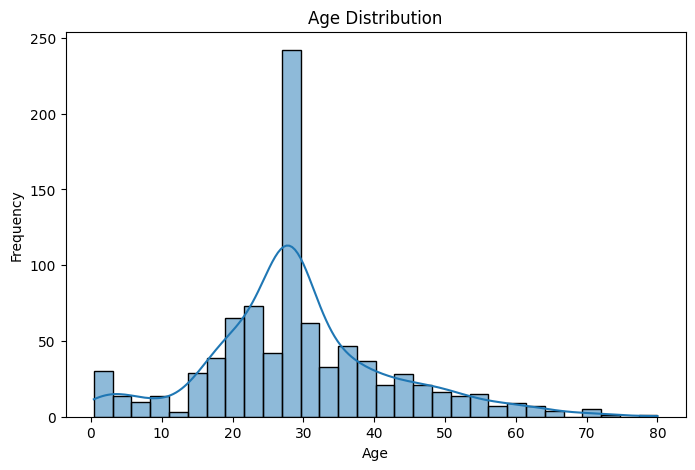

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    clean_df["age"],
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

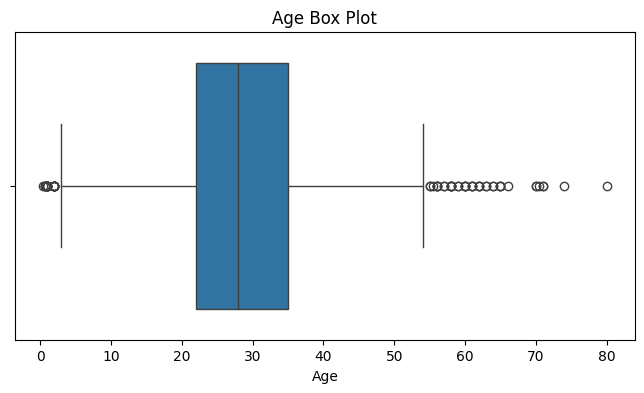

In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=clean_df["age"]
)

plt.title("Age Box Plot")
plt.xlabel("Age")

plt.show()

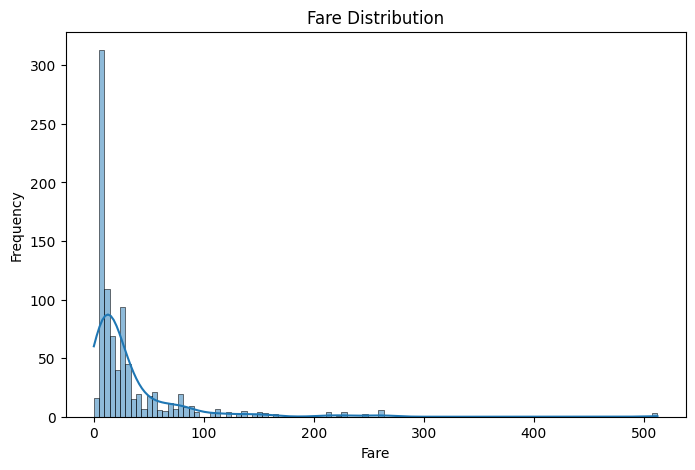

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    clean_df["fare"],
    kde=True
)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

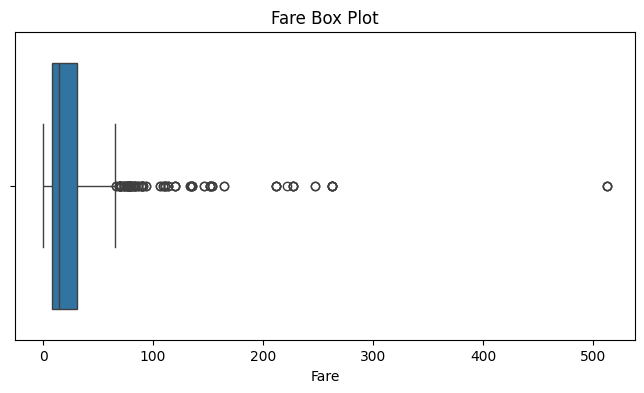

In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=clean_df["fare"]
)

plt.title("Fare Box Plot")
plt.xlabel("Fare")

plt.show()

In [ ]:
Q1_age = clean_df["age"].quantile(0.25)
Q3_age = clean_df["age"].quantile(0.75)

IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

age_outliers = clean_df[
    (clean_df["age"] < lower_age) |
    (clean_df["age"] > upper_age)
]

print("Age Q1:", Q1_age)
print("Age Q3:", Q3_age)
print("Age IQR:", IQR_age)
print("Lower bound:", lower_age)
print("Upper bound:", upper_age)

print(
    "\nNumber of age outliers:",
    len(age_outliers)
)

Age Q1: 22.0
Age Q3: 35.0
Age IQR: 13.0
Lower bound: 2.5
Upper bound: 54.5

Number of age outliers: 65


In [ ]:
Q1_fare = clean_df["fare"].quantile(0.25)
Q3_fare = clean_df["fare"].quantile(0.75)

IQR_fare = Q3_fare - Q1_fare

lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare

fare_outliers = clean_df[
    (clean_df["fare"] < lower_fare) |
    (clean_df["fare"] > upper_fare)
]

print("Fare Q1:", Q1_fare)
print("Fare Q3:", Q3_fare)
print("Fare IQR:", IQR_fare)
print("Lower bound:", lower_fare)
print("Upper bound:", upper_fare)

print(
    "\nNumber of fare outliers:",
    len(fare_outliers)
)

Fare Q1: 7.8958
Fare Q3: 31.0
Fare IQR: 23.1042
Lower bound: -26.7605
Upper bound: 65.6563

Number of fare outliers: 114


In [ ]:
fare_mean = clean_df["fare"].mean()
fare_median = clean_df["fare"].median()
fare_mode = clean_df["fare"].mode()[0]

print("Fare Mean  :", fare_mean)
print("Fare Median:", fare_median)
print("Fare Mode  :", fare_mode)

Fare Mean  : 32.09668087739032
Fare Median: 14.4542
Fare Mode  : 8.05


In [ ]:
if (
    fare_mean >
    fare_median >
    fare_mode
):

    print(
        "Fare distribution is RIGHT-SKEWED."
    )

elif (
    fare_mean <
    fare_median <
    fare_mode
):

    print(
        "Fare distribution is LEFT-SKEWED."
    )

else:

    print(
        "Fare does not follow a strict "
        "mean > median > mode or "
        "mean < median < mode pattern."
    )

Fare distribution is RIGHT-SKEWED.


In [ ]:
survival_by_sex = (
    clean_df
    .groupby("sex")["survived"]
    .mean()
    .mul(100)
    .round(2)
)

print("========== SURVIVAL BY SEX ==========")

display(
    survival_by_sex.to_frame(
        "Survival Rate (%)"
    )
)

========== SURVIVAL BY SEX ==========


,Survival Rate (%)
sex,
female,74.04
male,18.89


In [ ]:
survival_by_class = (
    clean_df
    .groupby("pclass")["survived"]
    .mean()
    .mul(100)
    .round(2)
)

print("========== SURVIVAL BY PCLASS ==========")

display(
    survival_by_class.to_frame(
        "Survival Rate (%)"
    )
)

========== SURVIVAL BY PCLASS ==========


,Survival Rate (%)
pclass,
1,62.62
2,47.28
3,24.24


In [ ]:
survival_by_sex_class = (
    clean_df
    .groupby(
        ["sex", "pclass"]
    )["survived"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
)

survival_by_sex_class.columns = [
    "sex",
    "pclass",
    "survival_rate_percent"
]

display(survival_by_sex_class)

,sex,pclass,survival_rate_percent
0,female,1,96.74
1,female,2,92.11
2,female,3,50.00
3,male,1,36.89
4,male,2,15.74
5,male,3,13.54


In [ ]:
female_first_class = clean_df[
    (clean_df["sex"] == "female") &
    (clean_df["pclass"] == 1)
]

print(
    "Female + First Class:",
    len(female_first_class)
)

Female + First Class: 92


In [ ]:
male_third_class = clean_df[
    (clean_df["sex"] == "male") &
    (clean_df["pclass"] == 3)
]

print(
    "Male + Third Class:",
    len(male_third_class)
)

Male + Third Class: 347


In [ ]:
female_or_first = clean_df[
    (clean_df["sex"] == "female") |
    (clean_df["pclass"] == 1)
]

print(
    "Female OR First Class:",
    len(female_or_first)
)

Female OR First Class: 434


In [ ]:
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = (
    clean_df[
        correlation_columns
    ].corr()
)

display(correlation_matrix)

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


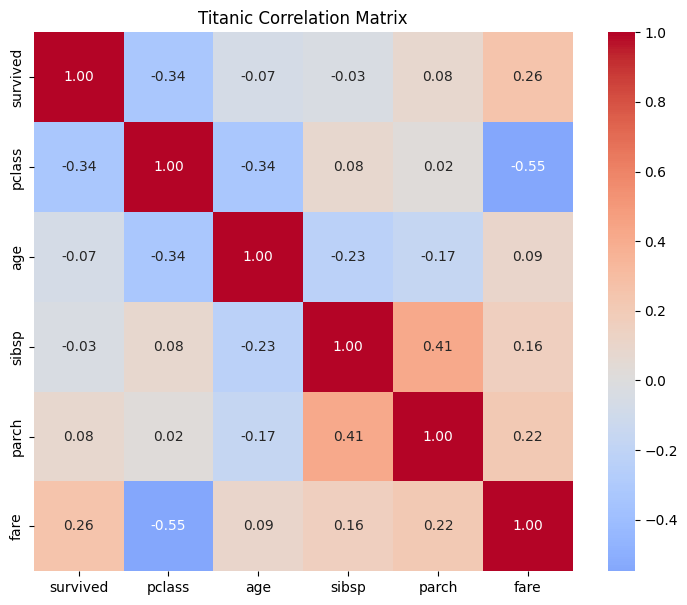

In [ ]:
plt.figure(
    figsize=(9, 7)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title(
    "Titanic Correlation Matrix"
)

plt.show()

In [ ]:
correlation_pairs = []

for i in range(
    len(correlation_columns)
):

    for j in range(
        i + 1,
        len(correlation_columns)
    ):

        col1 = correlation_columns[i]
        col2 = correlation_columns[j]

        value = correlation_matrix.loc[
            col1,
            col2
        ]

        correlation_pairs.append({
            "Feature 1": col1,
            "Feature 2": col2,
            "Correlation": value,
            "Absolute Correlation": abs(value)
        })

top_correlations = (
    pd.DataFrame(correlation_pairs)
    .sort_values(
        "Absolute Correlation",
        ascending=False
    )
    .head(2)
)

display(top_correlations)

,Feature 1,Feature 2,Correlation,Absolute Correlation
8,pclass,fare,-0.548193,0.548193
12,sibsp,parch,0.414542,0.414542


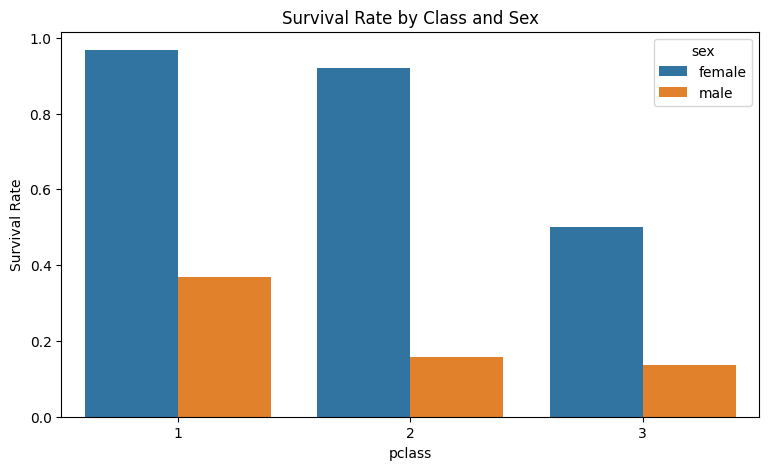

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=clean_df,
    x="pclass",
    y="survived",
    hue="sex",
    errorbar=None
)

plt.title(
    "Survival Rate by Class and Sex"
)

plt.ylabel("Survival Rate")

plt.show()

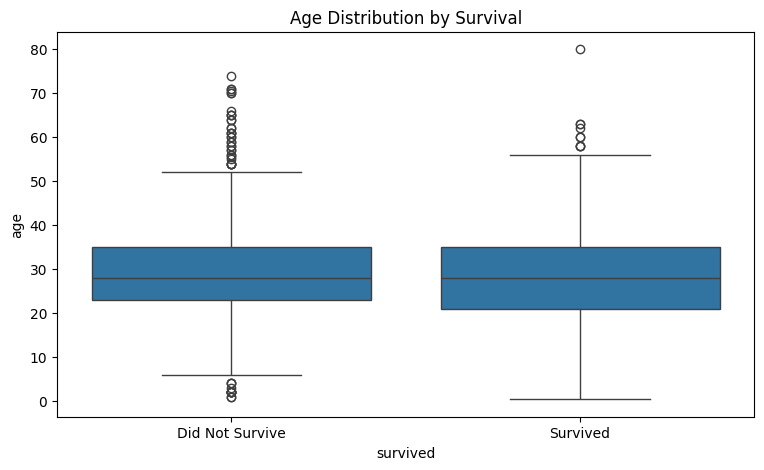

In [ ]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=clean_df,
    x="survived",
    y="age"
)

plt.xticks(
    [0, 1],
    ["Did Not Survive", "Survived"]
)

plt.title(
    "Age Distribution by Survival"
)

plt.show()

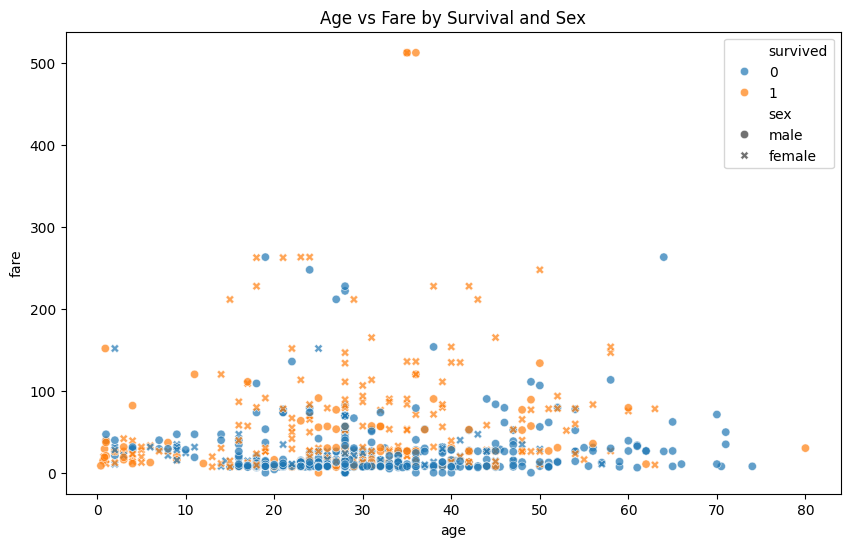

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clean_df,
    x="age",
    y="fare",
    hue="survived",
    style="sex",
    alpha=0.7
)

plt.title(
    "Age vs Fare by Survival and Sex"
)

plt.show()

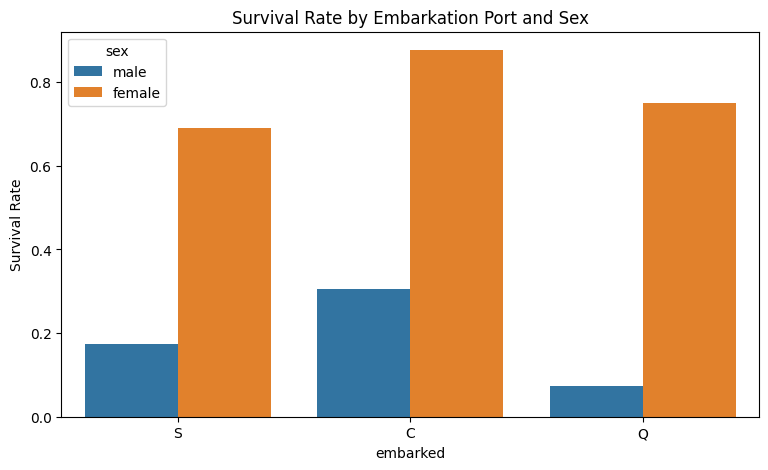

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=clean_df,
    x="embarked",
    y="survived",
    hue="sex",
    errorbar=None
)

plt.title(
    "Survival Rate by Embarkation Port and Sex"
)

plt.ylabel("Survival Rate")

plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

standardized = clean_df[
    ["age", "fare"]
].copy()

standardized[
    ["age", "fare"]
] = scaler.fit_transform(
    standardized[
        ["age", "fare"]
    ]
)

print("Before standardization:")
display(
    clean_df[
        ["age", "fare"]
    ].agg(["mean", "std"]).T
)

print("\nAfter standardization:")
display(
    standardized[
        ["age", "fare"]
    ].agg(["mean", "std"]).T
)

Before standardization:


,mean,std
age,29.315152,12.984932
fare,32.096681,49.697504



After standardization:


,mean,std
age,2.717486e-16,1.000563
fare,1.398706e-16,1.000563


In [ ]:
target = "survived"

features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = clean_df[features].copy()

y = clean_df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (889, 7)
y shape: (889,)


In [ ]:
class_counts = y.value_counts()

print("Class counts:")
display(class_counts)

print("\nClass percentages:")

class_percent = (
    y.value_counts(
        normalize=True
    ) * 100
).round(2)

display(class_percent)

Class counts:


,count
survived,
0,549
1,340



Class percentages:


,proportion
survived,
0,61.75
1,38.25


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (711, 7)
Testing data : (178, 7)


In [ ]:
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

In [ ]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])

In [ ]:
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

In [ ]:
preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

In [ ]:
logistic_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

logistic_pipeline.fit(
    X_train,
    y_train
)

logistic_pred = logistic_pipeline.predict(
    X_test
)

logistic_prob = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

print("Logistic Regression completed.")

Logistic Regression completed.


In [ ]:
tree_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        )
    )
])

tree_pipeline.fit(
    X_train,
    y_train
)

tree_pred = tree_pipeline.predict(
    X_test
)

tree_prob = tree_pipeline.predict_proba(
    X_test
)[:, 1]

print("Decision Tree completed.")

Decision Tree completed.


In [ ]:
rf_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        )
    )
])

rf_pipeline.fit(
    X_train,
    y_train
)

rf_pred = rf_pipeline.predict(
    X_test
)

rf_prob = rf_pipeline.predict_proba(
    X_test
)[:, 1]

print("Random Forest completed.")

Random Forest completed.


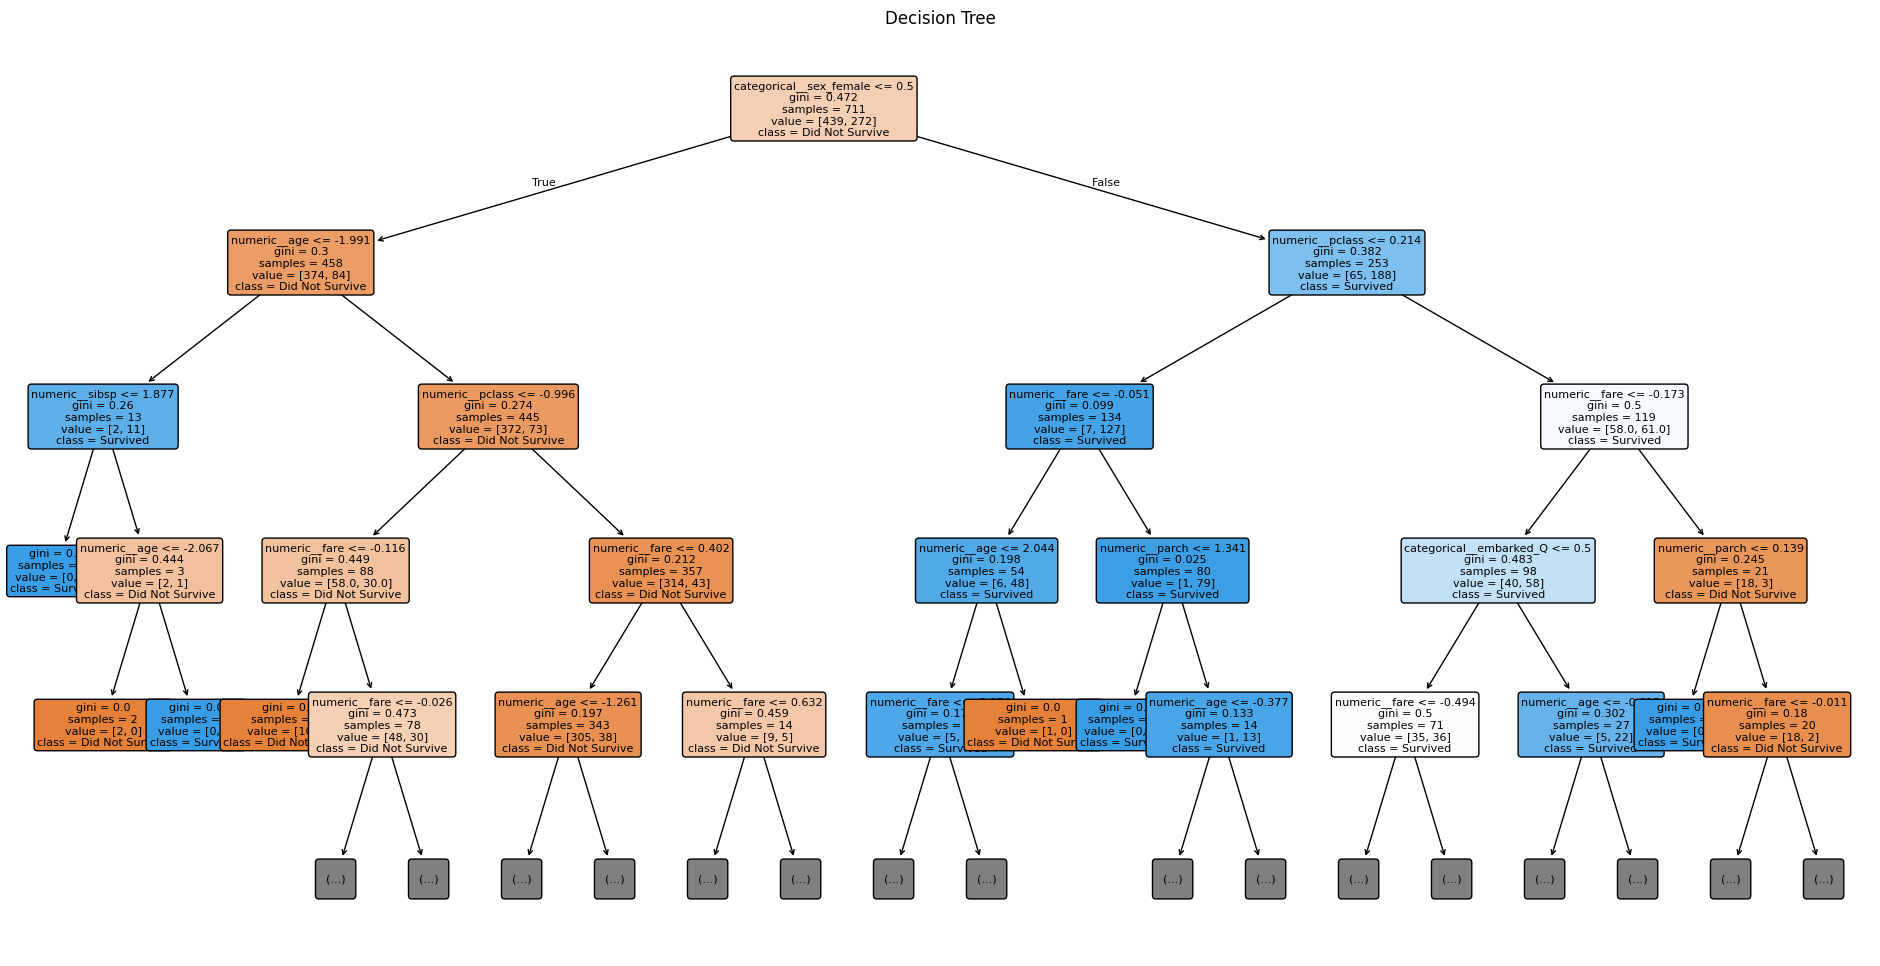

In [ ]:
tree_preprocessor = (
    tree_pipeline
    .named_steps["preprocessor"]
)

tree_model = (
    tree_pipeline
    .named_steps["model"]
)

feature_names = (
    tree_preprocessor
    .get_feature_names_out()
)

plt.figure(
    figsize=(24, 12)
)

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=[
        "Did Not Survive",
        "Survived"
    ],
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=8
)

plt.title(
    "Decision Tree"
)

plt.show()

In [ ]:
def evaluate_model(
    name,
    y_true,
    predictions,
    probabilities
):

    accuracy = accuracy_score(
        y_true,
        predictions
    )

    precision = precision_score(
        y_true,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        predictions,
        zero_division=0
    )

    auc = roc_auc_score(
        y_true,
        probabilities
    )

    cm = confusion_matrix(
        y_true,
        predictions
    )

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
        "Confusion Matrix": cm
    }

In [ ]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_pred,
        logistic_prob
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        tree_pred,
        tree_prob
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_prob
    )
)

results_df = pd.DataFrame(results)

display(
    results_df[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "AUC"
        ]
    ].round(4)
)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.7640,0.7600,0.5588,0.6441,0.8374
2,Random Forest,0.8034,0.7619,0.7059,0.7328,0.8237


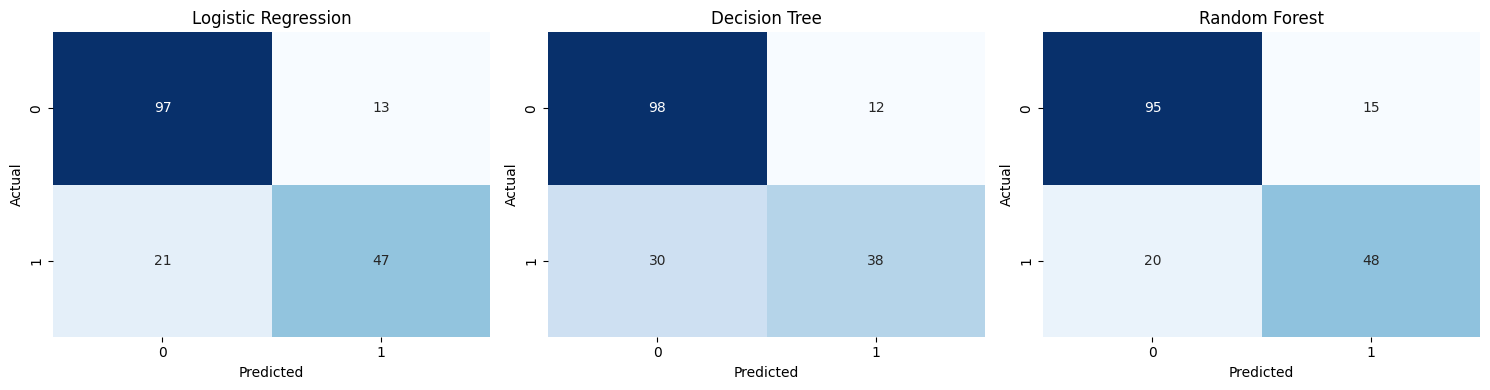

In [ ]:
models_predictions = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": tree_pred,
    "Random Forest": rf_pred
}

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

for ax, (name, predictions) in zip(
    axes,
    models_predictions.items()
):

    cm = confusion_matrix(
        y_test,
        predictions
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

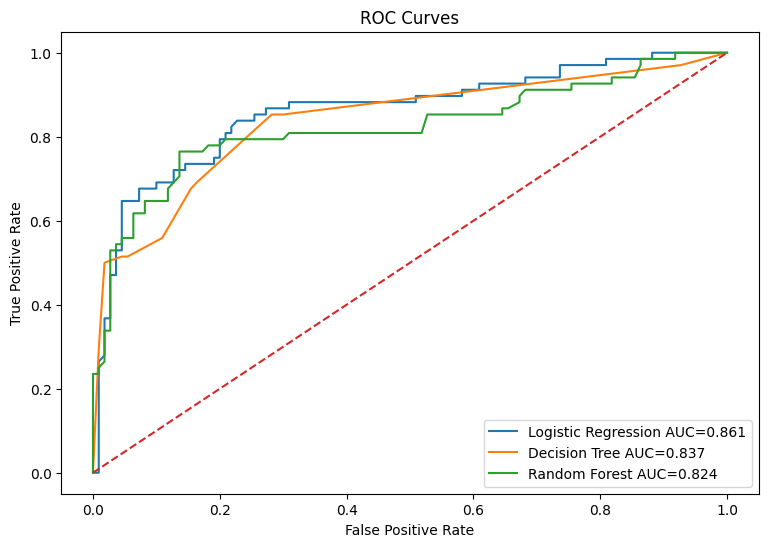

In [ ]:
plt.figure(
    figsize=(9, 6)
)

models_probabilities = {
    "Logistic Regression": logistic_prob,
    "Decision Tree": tree_prob,
    "Random Forest": rf_prob
}

for name, probabilities in models_probabilities.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} AUC={auc:.3f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curves"
)

plt.legend()

plt.show()

In [ ]:
baseline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

baseline.fit(
    X_train,
    y_train
)

baseline_pred = baseline.predict(
    X_test
)

In [ ]:
smote_preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

X_train_transformed = (
    smote_preprocessor.fit_transform(
        X_train
    )
)

X_test_transformed = (
    smote_preprocessor.transform(
        X_test
    )
)

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = (
    smote.fit_resample(
        X_train_transformed,
        y_train
    )
)

print(
    "Before SMOTE:",
    y_train.value_counts().to_dict()
)

print(
    "After SMOTE:",
    pd.Series(
        y_train_smote
    ).value_counts().to_dict()
)

Before SMOTE: {0: 439, 1: 272}
After SMOTE: {1: 439, 0: 439}


In [ ]:
smote_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

smote_model.fit(
    X_train_smote,
    y_train_smote
)

smote_pred = smote_model.predict(
    X_test_transformed
)

In [ ]:
imbalance_results = pd.DataFrame([
    {
        "Strategy": "Baseline",
        "Precision": precision_score(
            y_test,
            baseline_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            baseline_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            baseline_pred,
            zero_division=0
        )
    },

    {
        "Strategy": "Class Weight Balanced",
        "Precision": precision_score(
            y_test,
            balanced_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            balanced_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            balanced_pred,
            zero_division=0
        )
    },

    {
        "Strategy": "SMOTE",
        "Precision": precision_score(
            y_test,
            smote_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            smote_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            smote_pred,
            zero_division=0
        )
    }
])

display(
    imbalance_results.round(4)
)

,Strategy,Precision,Recall,F1
0,Baseline,0.7833,0.6912,0.7344
1,Class Weight Balanced,0.7183,0.7500,0.7338
2,SMOTE,0.7353,0.7353,0.7353


In [ ]:
rf_grid_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),

    (
        "model",
        RandomForestClassifier(
            oob_score=True,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [ ]:
param_grid = {
    "model__n_estimators": [
        100,
        200
    ],

    "model__max_depth": [
        None,
        5,
        10
    ],

    "model__max_features": [
        "sqrt",
        "log2"
    ]
}

In [ ]:
grid_search = GridSearchCV(
    rf_grid_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

print(
    "Best parameters:"
)

print(
    grid_search.best_params_
)

print(
    "\nBest CV F1:",
    grid_search.best_score_
)

Best parameters:
{'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__n_estimators': 200}

Best CV F1: 0.7408312771917277


In [ ]:
best_rf_pipeline = (
    grid_search.best_estimator_
)

best_rf_model = (
    best_rf_pipeline
    .named_steps["model"]
)

print(
    "OOB Score:",
    best_rf_model.oob_score_
)

OOB Score: 0.8213783403656821


In [ ]:
tuned_rf_pred = (
    best_rf_pipeline.predict(
        X_test
    )
)

tuned_rf_prob = (
    best_rf_pipeline
    .predict_proba(X_test)[:, 1]
)

tuned_rf_accuracy = accuracy_score(
    y_test,
    tuned_rf_pred
)

tuned_rf_precision = precision_score(
    y_test,
    tuned_rf_pred,
    zero_division=0
)

tuned_rf_recall = recall_score(
    y_test,
    tuned_rf_pred,
    zero_division=0
)

tuned_rf_f1 = f1_score(
    y_test,
    tuned_rf_pred,
    zero_division=0
)

tuned_rf_auc = roc_auc_score(
    y_test,
    tuned_rf_prob
)

print(
    "Tuned Random Forest"
)

print(
    "Accuracy :",
    tuned_rf_accuracy
)

print(
    "Precision:",
    tuned_rf_precision
)

print(
    "Recall   :",
    tuned_rf_recall
)

print(
    "F1       :",
    tuned_rf_f1
)

print(
    "AUC      :",
    tuned_rf_auc
)

Tuned Random Forest
Accuracy : 0.8314606741573034
Precision: 0.8653846153846154
Recall   : 0.6617647058823529
F1       : 0.75
AUC      : 0.838903743315508


In [ ]:
regression_features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"
]

X_reg = clean_df[
    regression_features
].copy()

y_reg = clean_df[
    "fare"
].copy()

In [ ]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

In [ ]:
reg_numeric = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

reg_categorical = [
    "sex",
    "embarked"
]

reg_preprocessor = ColumnTransformer([
    (
        "numeric",
        Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]),
        reg_numeric
    ),

    (
        "categorical",
        Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            )
        ]),
        reg_categorical
    )
])

In [ ]:
regression_pipeline = Pipeline([
    (
        "preprocessor",
        reg_preprocessor
    ),

    (
        "model",
        LinearRegression()
    )
])

regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)

fare_predictions = (
    regression_pipeline.predict(
        X_reg_test
    )
)

In [ ]:
mae = mean_absolute_error(
    y_reg_test,
    fare_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        fare_predictions
    )
)

r2 = r2_score(
    y_reg_test,
    fare_predictions
)

n = len(y_reg_test)

p = (
    regression_pipeline
    .named_steps["preprocessor"]
    .transform(X_reg_test)
    .shape[1]
)

adjusted_r2 = (
    1 -
    (
        (1 - r2) *
        (n - 1) /
        (n - p - 1)
    )
)

print("MAE        :", mae)
print("RMSE       :", rmse)
print("R²         :", r2)
print("Adjusted R²:", adjusted_r2)

MAE        : 21.138552296883095
RMSE       : 41.746502315739114
R²         : 0.34677389181134044
Adjusted R²: 0.3117796360155194


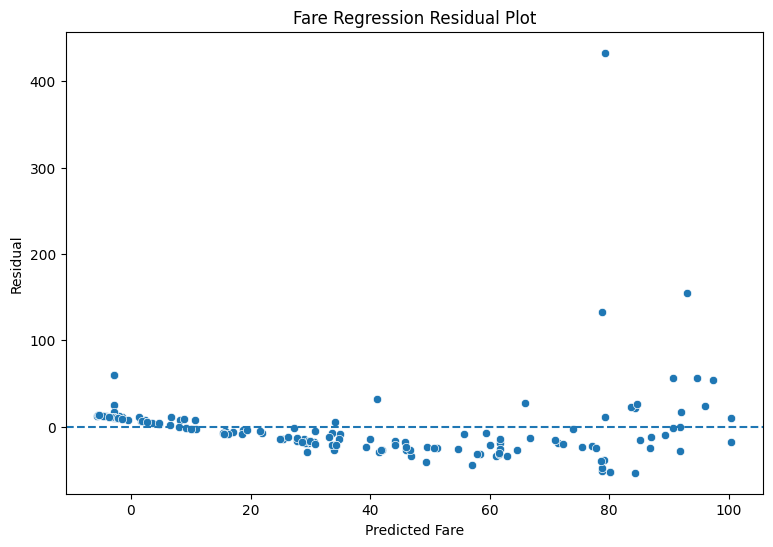

In [ ]:
residuals = (
    y_reg_test.values -
    fare_predictions
)

plt.figure(
    figsize=(9, 6)
)

sns.scatterplot(
    x=fare_predictions,
    y=residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Predicted Fare"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Fare Regression Residual Plot"
)

plt.show()

In [ ]:
X_bp = sm.add_constant(
    fare_predictions
)

bp_test = het_breuschpagan(
    residuals,
    X_bp
)

bp_pvalue = bp_test[1]

print(
    "Breusch-Pagan p-value:",
    bp_pvalue
)

if bp_pvalue < 0.05:

    print(
        "Conclusion: evidence of heteroscedasticity."
    )

else:

    print(
        "Conclusion: no statistically significant "
        "evidence of heteroscedasticity."
    )

Breusch-Pagan p-value: 0.04081358679558499
Conclusion: evidence of heteroscedasticity.


In [ ]:
final_results = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC"
    ]
].copy()

tuned_rf_row = pd.DataFrame([{
    "Model": "Tuned Random Forest",
    "Accuracy": tuned_rf_accuracy,
    "Precision": tuned_rf_precision,
    "Recall": tuned_rf_recall,
    "F1": tuned_rf_f1,
    "AUC": tuned_rf_auc
}])

final_results = pd.concat(
    [
        final_results,
        tuned_rf_row
    ],
    ignore_index=True
)

display(
    final_results.round(4)
)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.7640,0.7600,0.5588,0.6441,0.8374
2,Random Forest,0.8034,0.7619,0.7059,0.7328,0.8237
3,Tuned Random Forest,0.8315,0.8654,0.6618,0.7500,0.8389


In [ ]:
regression_results = pd.DataFrame([{
    "Model": "Linear Regression",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "Adjusted_R2": adjusted_r2
}])

display(
    regression_results.round(4)
)

,Model,MAE,RMSE,R2,Adjusted_R2
0,Linear Regression,21.1386,41.7465,0.3468,0.3118


In [ ]:
MODEL_PATH = (
    "/content/analytics/"
    "models/"
    "best_titanic_pipeline.joblib"
)

joblib.dump(
    best_rf_pipeline,
    MODEL_PATH
)

print(
    "Pipeline saved:"
)

print(
    MODEL_PATH
)

Pipeline saved:
/content/analytics/models/best_titanic_pipeline.joblib


In [ ]:
loaded_pipeline = joblib.load(
    MODEL_PATH
)

print(
    "Pipeline successfully reloaded."
)

Pipeline successfully reloaded.


In [ ]:
raw_test_rows = X_test.iloc[:5].copy()

predictions_after_reload = (
    loaded_pipeline.predict(
        raw_test_rows
    )
)

print(
    "Raw input:"
)

display(
    raw_test_rows
)

print(
    "Predictions:"
)

print(
    predictions_after_reload
)

Raw input:


,pclass,sex,age,sibsp,parch,fare,embarked
160,3,male,44.0,0,1,16.100,S
126,3,male,28.0,0,0,7.750,Q
428,3,male,28.0,0,0,7.750,Q
422,3,male,29.0,0,0,7.875,S
565,3,male,24.0,2,0,24.150,S


Predictions:
[0 0 0 0 0]


In [ ]:
assert len(
    predictions_after_reload
) == len(
    raw_test_rows
)

print(
    "SUCCESS: Complete pipeline works "
    "on raw, unprocessed data."
)

SUCCESS: Complete pipeline works on raw, unprocessed data.


In [ ]:
final_results.to_csv(
    "/content/analytics/"
    "classification_results.csv",
    index=False
)

imbalance_results.to_csv(
    "/content/analytics/"
    "imbalance_results.csv",
    index=False
)

regression_results.to_csv(
    "/content/analytics/"
    "regression_results.csv",
    index=False
)

correlation_matrix.to_csv(
    "/content/analytics/"
    "correlation_matrix.csv"
)

survival_by_sex.to_csv(
    "/content/analytics/"
    "survival_by_sex.csv"
)

survival_by_class.to_csv(
    "/content/analytics/"
    "survival_by_class.csv"
)

survival_by_sex_class.to_csv(
    "/content/analytics/"
    "survival_by_sex_and_class.csv",
    index=False
)

print(
    "All result files saved."
)

All result files saved.


In [ ]:
readme_text = f"""
# Module 2 — Analytics Pipeline

## Dataset

Titanic dataset loaded using Seaborn's built-in loader.

The raw dataset was saved immediately as:

titanic.csv

## Missing Value Strategy

Missing values were handled according to the required threshold:

- Under 5%: affected rows dropped.
- 5%–30%: imputation.
- Over 30%: column dropped when reliable imputation was not justified.

Measured missing percentages:

{missing_percent.to_string()}

## EDA

Age IQR outliers: {len(age_outliers)}

Fare IQR outliers: {len(fare_outliers)}

Fare mean: {fare_mean:.4f}

Fare median: {fare_median:.4f}

Fare mode: {fare_mode:.4f}

Fare distribution interpretation:
Mean/median/mode ordering was used to determine the skew direction.

## Modeling

A stratified train/test split was performed before preprocessing.

Models:
- Logistic Regression
- Decision Tree
- Random Forest

Preprocessing:
- Median imputation for numeric features
- Most-frequent imputation for categorical features
- One-hot encoding
- StandardScaler

## Imbalance

Compared:
- Baseline
- class_weight='balanced'
- SMOTE on training data only

## Random Forest Tuning

Best parameters:

{grid_search.best_params_}

Best CV F1:

{grid_search.best_score_:.4f}

OOB score:

{best_rf_model.oob_score_:.4f}

## Regression

Linear regression predicts fare from the other available features.

MAE: {mae:.4f}

RMSE: {rmse:.4f}

R2: {r2:.4f}

Adjusted R2: {adjusted_r2:.4f}

Breusch-Pagan p-value: {bp_pvalue:.4f}

## Saved Model

Complete preprocessing + Random Forest pipeline:

models/best_titanic_pipeline.joblib

The saved pipeline was reloaded and tested on raw input data.
"""

with open(
    "/content/analytics/README.md",
    "w",
    encoding="utf-8"
) as f:

    f.write(
        readme_text
    )

print(
    "README created."
)

README created.


In [ ]:
import os

for root, dirs, files in os.walk(
    "/content/analytics"
):

    level = root.replace(
        "/content/analytics",
        ""
    ).count(os.sep)

    indent = "    " * level

    print(
        indent +
        os.path.basename(root) +
        "/"
    )

    for file in files:

        print(
            "    " * (level + 1) +
            file
        )

analytics/
    survival_by_class.csv
    correlation_matrix.csv
    imbalance_results.csv
    titanic.csv
    survival_by_sex_and_class.csv
    regression_results.csv
    README.md
    survival_by_sex.csv
    classification_results.csv
    models/
        best_titanic_pipeline.joblib
    charts/


**Module:3**

In [ ]:
!pip install -q \
    chromadb \
    sentence-transformers \
    langgraph \
    langchain-core \
    fastapi \
    uvicorn \
    pydantic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.3/206.3 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently 

In [ ]:
import os
import json
import shutil
import textwrap
from pathlib import Path
from typing import TypedDict, List

import chromadb

from sentence_transformers import SentenceTransformer

from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END

from fastapi import FastAPI

In [ ]:
import os
import json
import re
import shutil
import time
from pathlib import Path
from typing import TypedDict, List, Dict, Any


os.environ["MOCK_LLM"] = "1"

MOCK_LLM = os.getenv("MOCK_LLM", "1") != "0"

print("MOCK_LLM =", MOCK_LLM)

MOCK_LLM = True


In [ ]:
from pathlib import Path

BASE_DIR = Path("/content/support_assistant")
DOCS_DIR = BASE_DIR / "docs"
DB_DIR = BASE_DIR / "chroma_db"

DOCS_DIR.mkdir(parents=True, exist_ok=True)
DB_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", BASE_DIR)
print("Documents directory:", DOCS_DIR)
print("ChromaDB directory:", DB_DIR)

Project directory: /content/support_assistant
Documents directory: /content/support_assistant/docs
ChromaDB directory: /content/support_assistant/chroma_db


In [ ]:


documents = {
    "doc_01": {
        "title": "Delivery Policy",
        "text": """Zepto delivers grocery and household essentials to serviceable pin codes within 10 to 30 minutes of order confirmation, depending on the customer's delivery zone and current order volume. Standard delivery is free on orders over INR 149; orders below this threshold incur a flat INR 25 delivery fee. Priority delivery, which reserves the next available rider slot, is available at checkout for an additional INR 15. Zepto does not currently deliver to addresses outside its listed serviceable pin codes."""
    },

    "doc_02": {
        "title": "Returns & Refunds",
        "text": """Grocery and perishable items may be reported for a return within 24 hours of delivery if damaged, spoiled, or incorrect; non-perishable packaged items may be returned within 7 days of delivery in unopened, resalable condition. Approved refunds are credited to the original payment method within 3–5 business days, or instantly to the Zepto wallet if the customer opts for wallet credit. Personal care items that have been opened are non-returnable except in the case of a manufacturing defect. Return pickup, where required, is arranged free of cost by Zepto."""
    },

    "doc_03": {
        "title": "Membership Tiers",
        "text": """Zepto offers three account tiers: Basic (free, default tier, standard delivery fees apply), Zepto Pass (INR 49 per month, free standard delivery on all orders and 5% off select categories), and Zepto Pass+ (INR 99 per month, free priority delivery, 10% off select categories, and early access to limited-time deals 24 hours before they go live to Basic and Pass members). Membership can be cancelled at any time from account settings; cancelling stops the next billing cycle but does not refund the current membership period."""
    },

    "doc_04": {
        "title": "Order Tracking",
        "text": """Every Zepto order shows a live rider-tracking map from the moment it is packed until delivery, accessible from the 'Track Order' screen. Estimated delivery time updates automatically as the rider moves. If an order's status shows no movement for more than 20 minutes past its original estimated delivery time, customers should contact support directly rather than continue waiting, since this indicates a likely delivery issue."""
    },

    "doc_05": {
        "title": "Order Cancellation Policy",
        "text": """Orders can be cancelled free of cost any time before the order status changes to 'Packed', typically within the first 2 minutes of placing the order. Once an order has been packed, it can no longer be cancelled through the app, since the rider is dispatched immediately after packing given Zepto's quick-delivery model. If a packed order cannot be delivered due to a Zepto-side issue (for example, rider unavailability), the order is auto-cancelled and fully refunded without any cancellation fee."""
    },

    "doc_06": {
        "title": "Damaged or Missing Items",
        "text": """If an order arrives with damaged, spoiled, or missing items, customers must report it within 24 hours of delivery through the 'Report an Issue' button on the order page. Zepto ships a free replacement or issues a full refund for damaged, spoiled, or missing items without requiring the customer to return the original item, unless the order value exceeds INR 1000, in which case a photo of the issue must be submitted through the report form before a replacement or refund is processed."""
    },

    "doc_07": {
        "title": "Gift Cards",
        "text": """Zepto gift cards are available in fixed denominations of INR 100, INR 250, INR 500, and INR 1000, and are delivered by email or SMS within minutes of purchase. Gift cards are valid for 1 year from the date of issue and carry no maintenance fees. Gift card balance can be combined with one other payment method at checkout but cannot be combined with another gift card in the same transaction. Gift card balance cannot be redeemed for cash except where required by law."""
    },

    "doc_08": {
        "title": "Customer Support Hours",
        "text": """Zepto customer support is available via in-app chat 24 hours a day, 7 days a week, given the time-sensitive nature of quick commerce deliveries. Average in-app chat response time is under 2 minutes. Email support is also available for non-urgent queries and is answered within 24 hours on business days. Phone support is not offered."""
    }
}

print("Total documents:", len(documents))

for doc_id, doc in documents.items():
    print(doc_id, ":", doc["title"])

Total documents: 8
doc_01 : Delivery Policy
doc_02 : Returns & Refunds
doc_03 : Membership Tiers
doc_04 : Order Tracking
doc_05 : Order Cancellation Policy
doc_06 : Damaged or Missing Items
doc_07 : Gift Cards
doc_08 : Customer Support Hours


In [ ]:
# ============================================================
# Save every file per document
# ============================================================

for doc_id, doc in documents.items():
    file_path = DOCS_DIR / f"{doc_id}.txt"

    with open(file_path, "w", encoding="utf-8") as f:
        f.write(doc["text"])

print("\nFiles created:\n")

for file in sorted(DOCS_DIR.glob("*.txt")):
    print(file.name)


Files created:

doc_01.txt
doc_02.txt
doc_03.txt
doc_04.txt
doc_05.txt
doc_06.txt
doc_07.txt
doc_08.txt


In [ ]:
# ============================================================
# LOCAL EMBEDDING MODEL
# ============================================================

from sentence_transformers import SentenceTransformer

EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"

print("Loading embedding model...")

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

print("Embedding model loaded:", EMBEDDING_MODEL_NAME)

Loading embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded: all-MiniLM-L6-v2


In [ ]:
# ============================================================
# CHROMADB
# ============================================================

import chromadb

chroma_client = chromadb.PersistentClient(
    path=str(DB_DIR)
)

collection = chroma_client.get_or_create_collection(
    name="zepto_policies",
    metadata={
        "hnsw:space": "cosine"
    }
)

print("Chroma collection created:")
print(collection.name)

Chroma collection created:
zepto_policies


In [ ]:
# ============================================================
# EMBEDDING + CHROMADB INGESTION
# ============================================================

doc_ids = list(documents.keys())

doc_texts = [
    documents[doc_id]["text"]
    for doc_id in doc_ids
]

doc_embeddings = embedding_model.encode(
    doc_texts,
    normalize_embeddings=True
).tolist()

metadatas = [
    {
        "doc_id": doc_id,
        "title": documents[doc_id]["title"]
    }
    for doc_id in doc_ids
]

# Remove previous records if this notebook is re-run
try:
    existing = collection.get()
    if existing and existing.get("ids"):
        collection.delete(ids=existing["ids"])
except Exception as e:
    print("Collection cleanup note:", e)

collection.add(
    ids=doc_ids,
    documents=doc_texts,
    embeddings=doc_embeddings,
    metadatas=metadatas
)

print("Successfully embedded and stored:", len(doc_ids), "documents")

Successfully embedded and stored: 8 documents


In [ ]:
# ============================================================
# VERIFY CHROMADB
# ============================================================

result = collection.get(
    include=["documents", "metadatas"]
)

print("Number of stored documents:", len(result["ids"]))

for i in range(len(result["ids"])):
    print(
        result["ids"][i],
        "->",
        result["metadatas"][i]["title"]
    )

Number of stored documents: 8
doc_01 -> Delivery Policy
doc_02 -> Returns & Refunds
doc_03 -> Membership Tiers
doc_04 -> Order Tracking
doc_05 -> Order Cancellation Policy
doc_06 -> Damaged or Missing Items
doc_07 -> Gift Cards
doc_08 -> Customer Support Hours


In [ ]:
# ============================================================
# RETRIEVAL FUNCTION
# ============================================================

def retrieve_documents(query: str, top_k: int = 3):
    """
    Embed the user query and retrieve top-k documents
    from ChromaDB using cosine similarity.
    """

    query_embedding = embedding_model.encode(
        [query],
        normalize_embeddings=True
    ).tolist()[0]

    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=top_k,
        include=[
            "documents",
            "metadatas",
            "distances"
        ]
    )

    retrieved = []

    for i in range(len(results["ids"][0])):
        retrieved.append({
            "id": results["ids"][0][i],
            "document": results["documents"][0][i],
            "metadata": results["metadatas"][0][i],
            "distance": results["distances"][0][i]
        })

    return retrieved

In [ ]:
query = "What is the delivery fee for an order below INR 149?"

retrieved = retrieve_documents(query)

for item in retrieved:
    print("\nID:", item["id"])
    print("Title:", item["metadata"]["title"])
    print("Distance:", item["distance"])
    print("Text:", item["document"][:200])


ID: doc_01
Title: Delivery Policy
Distance: 0.49358612298965454
Text: Zepto delivers grocery and household essentials to serviceable pin codes within 10 to 30 minutes of order confirmation, depending on the customer's delivery zone and current order volume. Standard del

ID: doc_05
Title: Order Cancellation Policy
Distance: 0.6598169803619385
Text: Orders can be cancelled free of cost any time before the order status changes to 'Packed', typically within the first 2 minutes of placing the order. Once an order has been packed, it can no longer be

ID: doc_07
Title: Gift Cards
Distance: 0.700931191444397
Text: Zepto gift cards are available in fixed denominations of INR 100, INR 250, INR 500, and INR 1000, and are delivered by email or SMS within minutes of purchase. Gift cards are valid for 1 year from the


In [ ]:
# ============================================================
# STRUCTURED PROMPT TEMPLATE
# ============================================================

PROMPT_TEMPLATE = """
ROLE:
You are a Zepto Customer Support Assistant. Answer customer
questions using only the supplied Zepto policy context.

CONTEXT:
{context}

TASK:
Answer the customer's question accurately using the retrieved
Zepto policy information.

FORMAT:
Return a concise answer in JSON format with:
{
  "answer": "your answer",
  "sources": ["document ids"],
  "confidence": 0.0
}

LENGTH:
Keep the answer under 100 words.

NEGATIVE CONSTRAINT:
Do not invent, assume, or use information that is not present
in the supplied context. If the context does not contain the
answer, state that the supplied policy context does not provide
the answer.

FEW-SHOT EXAMPLE:

User:
What is the delivery fee for orders below INR 149?

Context:
Standard delivery is free on orders over INR 149; orders below
this threshold incur a flat INR 25 delivery fee.

Assistant:
{
  "answer": "Orders below INR 149 incur a flat INR 25 delivery fee.",
  "sources": ["doc_01"],
  "confidence": 1.0
}

User Question:
{query}
"""

print(PROMPT_TEMPLATE)


ROLE:
You are a Zepto Customer Support Assistant. Answer customer
questions using only the supplied Zepto policy context.

CONTEXT:
{context}

TASK:
Answer the customer's question accurately using the retrieved
Zepto policy information.

FORMAT:
Return a concise answer in JSON format with:
{
  "answer": "your answer",
  "sources": ["document ids"],
  "confidence": 0.0
}

LENGTH:
Keep the answer under 100 words.

NEGATIVE CONSTRAINT:
Do not invent, assume, or use information that is not present
in the supplied context. If the context does not contain the
answer, state that the supplied policy context does not provide
the answer.

FEW-SHOT EXAMPLE:

User:
What is the delivery fee for orders below INR 149?

Context:
Standard delivery is free on orders over INR 149; orders below
this threshold incur a flat INR 25 delivery fee.

Assistant:
{
  "answer": "Orders below INR 149 incur a flat INR 25 delivery fee.",
  "sources": ["doc_01"],
  "confidence": 1.0
}

User Question:
{query}



In [ ]:
# ============================================================
# PYDANTIC RESPONSE MODEL
# ============================================================

from pydantic import BaseModel, Field, field_validator


class AnswerResponse(BaseModel):
    answer: str
    sources: List[str]
    confidence: float = Field(ge=0.0, le=1.0)

    @field_validator("answer")
    @classmethod
    def validate_answer(cls, value):
        if not value.strip():
            raise ValueError("Answer cannot be empty")
        return value


print(AnswerResponse(
    answer="Test answer",
    sources=["doc_01"],
    confidence=1.0
))

answer='Test answer' sources=['doc_01'] confidence=1.0


In [ ]:
# ============================================================
# LANGGRAPH STATE
# ============================================================

from langgraph.graph import StateGraph, START, END


class GraphState(TypedDict):
    query: str
    intent: str
    retrieved_docs: List[Dict[str, Any]]
    answer: str
    sources: List[str]
    confidence: float

In [ ]:
# ============================================================
# NODE 1 - CLASSIFY INTENT
# ============================================================

POLICY_KEYWORDS = [
    "delivery",
    "return",
    "refund",
    "membership",
    "tracking",
    "cancel",
    "gift card",
    "support hours"
]


def classify_intent(state: GraphState):
    query = state["query"].lower()

    # --------------------------------------------------------
    # MOCK MODE
    # --------------------------------------------------------
    if MOCK_LLM:

        if any(keyword in query for keyword in POLICY_KEYWORDS):
            intent = "policy_question"
        else:
            intent = "general_question"

        return {
            "intent": intent
        }

    # --------------------------------------------------------
    # OPTIONAL REAL LLM MODE
    # --------------------------------------------------------
    else:
        # Real LLM classification can be implemented here.
        # For safety, default to policy_question only when
        # policy-related keywords are detected.
        if any(keyword in query for keyword in POLICY_KEYWORDS):
            return {
                "intent": "policy_question"
            }

        return {
            "intent": "general_question"
        }

In [ ]:
# ============================================================
# NODE 2 - RETRIEVE AND ANSWER
# ============================================================

def retrieve_and_answer(state: GraphState):

    query = state["query"]

    # Always retrieve top-3 for policy questions
    retrieved = retrieve_documents(
        query=query,
        top_k=3
    )

    # --------------------------------------------------------
    # MOCK MODE
    # --------------------------------------------------------
    if MOCK_LLM:

        if len(retrieved) == 0:
            answer = "No relevant Zepto policy context was retrieved."
            sources = []
            confidence = 0.0

        else:
            top_chunk = retrieved[0]["document"]

            # Required style:
            # "Based on the retrieved context: ..."
            snippet = top_chunk[:200]

            answer = (
                f"Based on the retrieved context: {snippet}"
            )

            sources = [
                item["metadata"]["doc_id"]
                for item in retrieved
            ]

            confidence = 1.0

        return {
            "retrieved_docs": retrieved,
            "answer": answer,
            "sources": sources,
            "confidence": confidence
        }

    # --------------------------------------------------------
    # OPTIONAL REAL LLM MODE
    # --------------------------------------------------------
    else:

        context = "\n\n".join(
            [
                f"[{item['metadata']['doc_id']}] "
                f"{item['document']}"
                for item in retrieved
            ]
        )

        prompt = PROMPT_TEMPLATE.format(
            context=context,
            query=query
        )

        # Optional real LLM implementation
        response = call_real_llm_with_validation(
            prompt=prompt,
            query=query,
            retrieved=retrieved
        )

        return {
            "retrieved_docs": retrieved,
            "answer": response.answer,
            "sources": response.sources,
            "confidence": response.confidence
        }

In [ ]:
# ============================================================
# NODE 3 - DIRECT ANSWER
# ============================================================

def direct_answer(state: GraphState):

    # --------------------------------------------------------
    # MOCK MODE
    # --------------------------------------------------------
    if MOCK_LLM:

        return {
            "answer": "I can only answer questions about Zepto policies right now.",
            "sources": [],
            "confidence": 1.0
        }

    # --------------------------------------------------------
    # OPTIONAL REAL LLM MODE
    # --------------------------------------------------------
    else:

        query = state["query"]

        prompt = f"""
ROLE:
You are a Zepto Support Assistant.

TASK:
Answer the following general question.

FORMAT:
Return JSON:
{{
    "answer": "...",
    "sources": [],
    "confidence": 0.0
}}

NEGATIVE CONSTRAINT:
Do not claim that information is a Zepto policy unless it is
actually supplied in the question or retrieved context.

LENGTH:
Keep the answer under 100 words.

Question:
{query}
"""

        response = call_real_llm_with_validation(
            prompt=prompt,
            query=query,
            retrieved=[]
        )

        return {
            "answer": response.answer,
            "sources": response.sources,
            "confidence": response.confidence
        }

In [ ]:
# ============================================================
# CONDITIONAL ROUTER
# ============================================================

def route_intent(state: GraphState):

    if state["intent"] == "policy_question":
        return "policy_question"

    return "general_question"

In [ ]:
# ============================================================
# OPTIONAL REAL LLM SUPPORT
# ============================================================

def clean_json_response(raw_text: str) -> str:
    """
    Removes common markdown JSON fences.
    """

    text = raw_text.strip()

    if text.startswith("```json"):
        text = text[7:]

    if text.startswith("```"):
        text = text[3:]

    if text.endswith("```"):
        text = text[:-3]

    return text.strip()


def call_real_llm_with_validation(
    prompt: str,
    query: str,
    retrieved: list
) -> AnswerResponse:

    """
    Optional real LLM path.

    Attempts:
      1 initial response
      2 first corrective retry
      3 second corrective retry

    Total maximum = 3 attempts.
    """

    try:
        from langchain_groq import ChatGroq
    except ImportError:
        raise RuntimeError(
            "Install langchain-groq and configure GROQ_API_KEY "
            "when MOCK_LLM=0."
        )

    api_key = os.getenv("GROQ_API_KEY")

    if not api_key:
        raise RuntimeError(
            "GROQ_API_KEY is required when MOCK_LLM=0."
        )

    llm = ChatGroq(
        model="llama-3.1-8b-instant",
        temperature=0,
        api_key=api_key
    )

    current_prompt = prompt

    for attempt in range(3):

        try:

            raw_response = llm.invoke(
                current_prompt
            )

            raw_text = raw_response.content

            cleaned = clean_json_response(
                raw_text
            )

            parsed = json.loads(cleaned)

            validated = AnswerResponse.model_validate(
                parsed
            )

            return validated

        except Exception as e:

            if attempt == 2:

                return AnswerResponse(
                    answer="The assistant could not validate the generated response.",
                    sources=[],
                    confidence=0.0
                )

            current_prompt = f"""
The previous response failed Pydantic validation.

Validation error:
{str(e)}

Return ONLY valid JSON matching this exact schema:

{{
    "answer": "string",
    "sources": ["string"],
    "confidence": 0.0
}}

Do not include Markdown fences.

Original task:
{prompt}
"""

    return AnswerResponse(
        answer="Unable to generate a valid response.",
        sources=[],
        confidence=0.0
    )

In [ ]:
# ============================================================
# BUILD LANGGRAPH
# ============================================================

workflow = StateGraph(GraphState)

# Add required nodes
workflow.add_node(
    "classify_intent",
    classify_intent
)

workflow.add_node(
    "retrieve_and_answer",
    retrieve_and_answer
)

workflow.add_node(
    "direct_answer",
    direct_answer
)

# Start
workflow.add_edge(
    START,
    "classify_intent"
)

# Conditional edge
workflow.add_conditional_edges(
    "classify_intent",
    route_intent,
    {
        "policy_question": "retrieve_and_answer",
        "general_question": "direct_answer"
    }
)

# End edges
workflow.add_edge(
    "retrieve_and_answer",
    END
)

workflow.add_edge(
    "direct_answer",
    END
)

# Compile
support_graph = workflow.compile()

print("LangGraph compiled successfully.")

LangGraph compiled successfully.


In [ ]:
# ============================================================
# MAIN ASK FUNCTION
# ============================================================

def ask_zepto(query: str) -> AnswerResponse:

    if not isinstance(query, str):
        raise ValueError("query must be a string")

    if not query.strip():
        raise ValueError("query cannot be empty")

    initial_state = {
        "query": query,
        "intent": "",
        "retrieved_docs": [],
        "answer": "",
        "sources": [],
        "confidence": 0.0
    }

    result = support_graph.invoke(
        initial_state
    )

    response = AnswerResponse(
        answer=result["answer"],
        sources=result["sources"],
        confidence=result["confidence"]
    )

    return response

In [ ]:
# ============================================================
# TEST 1 - POLICY QUESTION
# ============================================================

query1 = "What is the delivery fee for orders below INR 149?"

response1 = ask_zepto(query1)

print("QUESTION:")
print(query1)

print("\nRESPONSE:")
print(response1.model_dump_json(indent=2))

QUESTION:
What is the delivery fee for orders below INR 149?

RESPONSE:
{
  "answer": "Based on the retrieved context: Zepto delivers grocery and household essentials to serviceable pin codes within 10 to 30 minutes of order confirmation, depending on the customer's delivery zone and current order volume. Standard del",
  "sources": [
    "doc_01",
    "doc_05",
    "doc_03"
  ],
  "confidence": 1.0
}


In [ ]:
# ============================================================
# TEST 2 - RETURNS
# ============================================================

query2 = "How long can I report a damaged grocery item?"

response2 = ask_zepto(query2)

print(response2.model_dump_json(indent=2))

{
  "answer": "I can only answer questions about Zepto policies right now.",
  "sources": [],
  "confidence": 1.0
}


In [ ]:
# ============================================================
# TEST 3 - MEMBERSHIP
# ============================================================

query3 = "How much does Zepto Pass cost?"

response3 = ask_zepto(query3)

print(response3.model_dump_json(indent=2))

{
  "answer": "I can only answer questions about Zepto policies right now.",
  "sources": [],
  "confidence": 1.0
}


In [ ]:
# ============================================================
# TEST 4 - CANCELLATION
# ============================================================

query4 = "Can I cancel my order before it is packed?"

response4 = ask_zepto(query4)

print(response4.model_dump_json(indent=2))

{
  "answer": "Based on the retrieved context: Orders can be cancelled free of cost any time before the order status changes to 'Packed', typically within the first 2 minutes of placing the order. Once an order has been packed, it can no longer be",
  "sources": [
    "doc_05",
    "doc_02",
    "doc_06"
  ],
  "confidence": 1.0
}


In [ ]:
# ============================================================
# TEST 5 - GENERAL QUESTION
# ============================================================

query5 = "What is the capital of France?"

response5 = ask_zepto(query5)

print(response5.model_dump_json(indent=2))

{
  "answer": "I can only answer questions about Zepto policies right now.",
  "sources": [],
  "confidence": 1.0
}


In [ ]:
# ============================================================
# ROUTING TESTS
# ============================================================

test_queries = [
    "How fast is delivery?",
    "How do I return an item?",
    "When will I get my refund?",
    "What is Zepto membership?",
    "Where can I track my order?",
    "Can I cancel my order?",
    "What gift cards are available?",
    "What are the support hours?",
    "Tell me a joke."
]

for q in test_queries:

    state = {
        "query": q,
        "intent": "",
        "retrieved_docs": [],
        "answer": "",
        "sources": [],
        "confidence": 0.0
    }

    classified = classify_intent(state)

    print(
        f"{q}\n"
        f" -> {classified['intent']}\n"
    )

How fast is delivery?
 -> policy_question

How do I return an item?
 -> policy_question

When will I get my refund?
 -> policy_question

What is Zepto membership?
 -> policy_question

Where can I track my order?
 -> general_question

Can I cancel my order?
 -> policy_question

What gift cards are available?
 -> policy_question

What are the support hours?
 -> policy_question

Tell me a joke.
 -> general_question



In [ ]:
# ============================================================
# DEMONSTRATE THE 3 GRAPH NODES
# ============================================================

print("Required LangGraph nodes:")
print("1. classify_intent")
print("2. retrieve_and_answer")
print("3. direct_answer")

print("\nConditional routing:")
print("policy_question  -> retrieve_and_answer")
print("general_question -> direct_answer")

Required LangGraph nodes:
1. classify_intent
2. retrieve_and_answer
3. direct_answer

Conditional routing:
policy_question  -> retrieve_and_answer
general_question -> direct_answer


In [ ]:
# ============================================================
# RETRIEVAL CORRECTNESS TESTS
# ============================================================

retrieval_tests = [
    (
        "What is the delivery fee for orders below INR 149?",
        "doc_01"
    ),
    (
        "How long can I return a damaged grocery item?",
        "doc_02"
    ),
    (
        "How much is Zepto Pass?",
        "doc_03"
    ),
    (
        "How can I track my order?",
        "doc_04"
    ),
    (
        "Can I cancel my order?",
        "doc_05"
    ),
    (
        "What happens if an item is missing?",
        "doc_06"
    ),
    (
        "What denominations are Zepto gift cards?",
        "doc_07"
    ),
    (
        "What are Zepto support hours?",
        "doc_08"
    )
]

passed = 0

for query, expected_doc in retrieval_tests:

    results = retrieve_documents(
        query,
        top_k=3
    )

    returned_ids = [
        x["id"]
        for x in results
    ]

    success = expected_doc in returned_ids

    print(
        f"Query: {query}\n"
        f"Expected: {expected_doc}\n"
        f"Retrieved: {returned_ids}\n"
        f"PASS: {success}\n"
    )

    if success:
        passed += 1

print(
    f"\nRetrieval test result: {passed}/{len(retrieval_tests)} passed."
)

Query: What is the delivery fee for orders below INR 149?
Expected: doc_01
Retrieved: ['doc_01', 'doc_05', 'doc_03']
PASS: True

Query: How long can I return a damaged grocery item?
Expected: doc_02
Retrieved: ['doc_02', 'doc_06', 'doc_05']
PASS: True

Query: How much is Zepto Pass?
Expected: doc_03
Retrieved: ['doc_03', 'doc_01', 'doc_07']
PASS: True

Query: How can I track my order?
Expected: doc_04
Retrieved: ['doc_04', 'doc_06', 'doc_01']
PASS: True

Query: Can I cancel my order?
Expected: doc_05
Retrieved: ['doc_05', 'doc_06', 'doc_02']
PASS: True

Query: What happens if an item is missing?
Expected: doc_06
Retrieved: ['doc_06', 'doc_02', 'doc_05']
PASS: True

Query: What denominations are Zepto gift cards?
Expected: doc_07
Retrieved: ['doc_07', 'doc_01', 'doc_03']
PASS: True

Query: What are Zepto support hours?
Expected: doc_08
Retrieved: ['doc_08', 'doc_03', 'doc_04']
PASS: True


Retrieval test result: 8/8 passed.


In [ ]:
# ============================================================
# FASTAPI APPLICATION
# ============================================================

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel


class AskRequest(BaseModel):
    query: str


app = FastAPI(
    title="Zepto Support Assistant",
    description="Offline deterministic Zepto policy support service",
    version="1.0.0"
)


@app.get("/")
def root():
    return {
        "service": "Zepto Support Assistant",
        "status": "running",
        "mock_llm": MOCK_LLM
    }


@app.get("/health")
def health():
    return {
        "status": "healthy"
    }


@app.post(
    "/ask",
    response_model=AnswerResponse
)
def ask_endpoint(request: AskRequest):

    try:

        response = ask_zepto(
            request.query
        )

        return response

    except ValueError as e:

        raise HTTPException(
            status_code=400,
            detail=str(e)
        )

    except Exception as e:

        raise HTTPException(
            status_code=500,
            detail=str(e)
        )

In [ ]:
# ============================================================
# SAVE CURRENT COLAB PROGRAM AS main.py
# ============================================================

main_py = r'''
import os
import json
from pathlib import Path
from typing import TypedDict, List, Dict, Any

import chromadb
from sentence_transformers import SentenceTransformer
from pydantic import BaseModel, Field, field_validator
from fastapi import FastAPI, HTTPException
from langgraph.graph import StateGraph, START, END


BASE_DIR = Path(__file__).resolve().parent
DOCS_DIR = BASE_DIR / "docs"
DB_DIR = BASE_DIR / "chroma_db"

MOCK_LLM = os.getenv("MOCK_LLM", "1") != "0"

EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"


DOCUMENTS = {
    "doc_01": {
        "title": "Delivery Policy",
        "text": """Zepto delivers grocery and household essentials to serviceable pin codes within 10 to 30 minutes of order confirmation, depending on the customer's delivery zone and current order volume. Standard delivery is free on orders over INR 149; orders below this threshold incur a flat INR 25 delivery fee. Priority delivery, which reserves the next available rider slot, is available at checkout for an additional INR 15. Zepto does not currently deliver to addresses outside its listed serviceable pin codes."""
    },
    "doc_02": {
        "title": "Returns & Refunds",
        "text": """Grocery and perishable items may be reported for a return within 24 hours of delivery if damaged, spoiled, or incorrect; non-perishable packaged items may be returned within 7 days of delivery in unopened, resalable condition. Approved refunds are credited to the original payment method within 3–5 business days, or instantly to the Zepto wallet if the customer opts for wallet credit. Personal care items that have been opened are non-returnable except in the case of a manufacturing defect. Return pickup, where required, is arranged free of cost by Zepto."""
    },
    "doc_03": {
        "title": "Membership Tiers",
        "text": """Zepto offers three account tiers: Basic (free, default tier, standard delivery fees apply), Zepto Pass (INR 49 per month, free standard delivery on all orders and 5% off select categories), and Zepto Pass+ (INR 99 per month, free priority delivery, 10% off select categories, and early access to limited-time deals 24 hours before they go live to Basic and Pass members). Membership can be cancelled at any time from account settings; cancelling stops the next billing cycle but does not refund the current membership period."""
    },
    "doc_04": {
        "title": "Order Tracking",
        "text": """Every Zepto order shows a live rider-tracking map from the moment it is packed until delivery, accessible from the 'Track Order' screen. Estimated delivery time updates automatically as the rider moves. If an order's status shows no movement for more than 20 minutes past its original estimated delivery time, customers should contact support directly rather than continue waiting, since this indicates a likely delivery issue."""
    },
    "doc_05": {
        "title": "Order Cancellation Policy",
        "text": """Orders can be cancelled free of cost any time before the order status changes to 'Packed', typically within the first 2 minutes of placing the order. Once an order has been packed, it can no longer be cancelled through the app, since the rider is dispatched immediately after packing given Zepto's quick-delivery model. If a packed order cannot be delivered due to a Zepto-side issue (for example, rider unavailability), the order is auto-cancelled and fully refunded without any cancellation fee."""
    },
    "doc_06": {
        "title": "Damaged or Missing Items",
        "text": """If an order arrives with damaged, spoiled, or missing items, customers must report it within 24 hours of delivery through the 'Report an Issue' button on the order page. Zepto ships a free replacement or issues a full refund for damaged, spoiled, or missing items without requiring the customer to return the original item, unless the order value exceeds INR 1000, in which case a photo of the issue must be submitted through the report form before a replacement or refund is processed."""
    },
    "doc_07": {
        "title": "Gift Cards",
        "text": """Zepto gift cards are available in fixed denominations of INR 100, INR 250, INR 500, and INR 1000, and are delivered by email or SMS within minutes of purchase. Gift cards are valid for 1 year from the date of issue and carry no maintenance fees. Gift card balance can be combined with one other payment method at checkout but cannot be combined with another gift card in the same transaction. Gift card balance cannot be redeemed for cash except where required by law."""
    },
    "doc_08": {
        "title": "Customer Support Hours",
        "text": """Zepto customer support is available via in-app chat 24 hours a day, 7 days a week, given the time-sensitive nature of quick commerce deliveries. Average in-app chat response time is under 2 minutes. Email support is also available for non-urgent queries and is answered within 24 hours on business days. Phone support is not offered."""
    }
}


embedding_model = SentenceTransformer(
    EMBEDDING_MODEL_NAME
)

chroma_client = chromadb.PersistentClient(
    path=str(DB_DIR)
)

collection = chroma_client.get_or_create_collection(
    name="zepto_policies",
    metadata={"hnsw:space": "cosine"}
)


def initialize_database():

    existing = collection.get()

    if existing.get("ids"):
        return

    ids = list(DOCUMENTS.keys())

    texts = [
        DOCUMENTS[x]["text"]
        for x in ids
    ]

    embeddings = embedding_model.encode(
        texts,
        normalize_embeddings=True
    ).tolist()

    metadatas = [
        {
            "doc_id": x,
            "title": DOCUMENTS[x]["title"]
        }
        for x in ids
    ]

    collection.add(
        ids=ids,
        documents=texts,
        embeddings=embeddings,
        metadatas=metadatas
    )


initialize_database()


def retrieve_documents(query: str, top_k: int = 3):

    query_embedding = embedding_model.encode(
        [query],
        normalize_embeddings=True
    ).tolist()[0]

    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=top_k,
        include=[
            "documents",
            "metadatas",
            "distances"
        ]
    )

    retrieved = []

    for i in range(len(results["ids"][0])):

        retrieved.append({
            "id": results["ids"][0][i],
            "document": results["documents"][0][i],
            "metadata": results["metadatas"][0][i],
            "distance": results["distances"][0][i]
        })

    return retrieved


class AnswerResponse(BaseModel):

    answer: str
    sources: List[str]
    confidence: float = Field(
        ge=0.0,
        le=1.0
    )

    @field_validator("answer")
    @classmethod
    def validate_answer(cls, value):

        if not value.strip():
            raise ValueError(
                "Answer cannot be empty"
            )

        return value


class GraphState(TypedDict):

    query: str
    intent: str
    retrieved_docs: List[Dict[str, Any]]
    answer: str
    sources: List[str]
    confidence: float


POLICY_KEYWORDS = [
    "delivery",
    "return",
    "refund",
    "membership",
    "tracking",
    "cancel",
    "gift card",
    "support hours"
]


def classify_intent(state: GraphState):

    query = state["query"].lower()

    if any(
        keyword in query
        for keyword in POLICY_KEYWORDS
    ):

        return {
            "intent": "policy_question"
        }

    return {
        "intent": "general_question"
    }


def retrieve_and_answer(state: GraphState):

    retrieved = retrieve_documents(
        state["query"],
        top_k=3
    )

    if not retrieved:

        return {
            "retrieved_docs": [],
            "answer": "No relevant Zepto policy context was retrieved.",
            "sources": [],
            "confidence": 0.0
        }

    top_chunk = retrieved[0]["document"]

    answer = (
        "Based on the retrieved context: "
        + top_chunk[:200]
    )

    sources = [
        item["metadata"]["doc_id"]
        for item in retrieved
    ]

    return {
        "retrieved_docs": retrieved,
        "answer": answer,
        "sources": sources,
        "confidence": 1.0
    }


def direct_answer(state: GraphState):

    return {
        "answer": "I can only answer questions about Zepto policies right now.",
        "sources": [],
        "confidence": 1.0
    }


def route_intent(state: GraphState):

    if state["intent"] == "policy_question":
        return "policy_question"

    return "general_question"


workflow = StateGraph(GraphState)

workflow.add_node(
    "classify_intent",
    classify_intent
)

workflow.add_node(
    "retrieve_and_answer",
    retrieve_and_answer
)

workflow.add_node(
    "direct_answer",
    direct_answer
)

workflow.add_edge(
    START,
    "classify_intent"
)

workflow.add_conditional_edges(
    "classify_intent",
    route_intent,
    {
        "policy_question": "retrieve_and_answer",
        "general_question": "direct_answer"
    }
)

workflow.add_edge(
    "retrieve_and_answer",
    END
)

workflow.add_edge(
    "direct_answer",
    END
)

support_graph = workflow.compile()


def ask_zepto(query: str):

    if not query.strip():
        raise ValueError(
            "query cannot be empty"
        )

    state = {
        "query": query,
        "intent": "",
        "retrieved_docs": [],
        "answer": "",
        "sources": [],
        "confidence": 0.0
    }

    result = support_graph.invoke(state)

    return AnswerResponse(
        answer=result["answer"],
        sources=result["sources"],
        confidence=result["confidence"]
    )


class AskRequest(BaseModel):
    query: str


app = FastAPI(
    title="Zepto Support Assistant",
    version="1.0.0"
)


@app.get("/")
def root():

    return {
        "service": "Zepto Support Assistant",
        "status": "running",
        "mock_llm": MOCK_LLM
    }


@app.get("/health")
def health():

    return {
        "status": "healthy"
    }


@app.post(
    "/ask",
    response_model=AnswerResponse
)
def ask_endpoint(
    request: AskRequest
):

    try:

        return ask_zepto(
            request.query
        )

    except ValueError as e:

        raise HTTPException(
            status_code=400,
            detail=str(e)
        )
'''

main_path = BASE_DIR / "main.py"

with open(main_path, "w", encoding="utf-8") as f:
    f.write(main_py)

print("Created:", main_path)

Created: /content/support_assistant/main.py


In [ ]:
# ============================================================
# REQUIREMENTS.TXT
# ============================================================

requirements = """chromadb
sentence-transformers
langgraph
langchain-core
fastapi
uvicorn
pydantic
requests
"""

requirements_path = BASE_DIR / "requirements.txt"

with open(
    requirements_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(requirements)

print(requirements_path.read_text())

chromadb
sentence-transformers
langgraph
langchain-core
fastapi
uvicorn
pydantic
requests



In [ ]:
# ============================================================
# DOCKERFILE
# ============================================================

dockerfile = """FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY . .

ENV MOCK_LLM=1

EXPOSE 7860

CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "7860"]
"""

docker_path = BASE_DIR / "Dockerfile"

with open(
    docker_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(dockerfile)

print(docker_path.read_text())

FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY . .

ENV MOCK_LLM=1

EXPOSE 7860

CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "7860"]



In [ ]:
# ============================================================
# README.MD
# ============================================================

readme = r"""# Zepto Support Assistant

## Module 3 - Support Assistant

This project implements an offline deterministic Zepto customer
support assistant using:

- Python
- Sentence Transformers
- all-MiniLM-L6-v2
- ChromaDB
- LangGraph
- Pydantic
- FastAPI
- Uvicorn
- Docker

## Architecture

The data flow is:

User Query
    |
    v
classify_intent
    |
    +----------------------------+
    |                            |
policy_question            general_question
    |                            |
    v                            v
retrieve_and_answer        direct_answer
    |
    v
Pydantic Response
    |
    v
FastAPI /ask

## Ingestion

Eight Zepto policy documents are stored in the `docs` directory.

Each document is embedded using:

`all-MiniLM-L6-v2`

Embeddings are stored in ChromaDB.

The ChromaDB collection is:

`zepto_policies`

## Retrieval

For policy questions, the query is embedded locally and the
top three chunks/documents are retrieved from ChromaDB using
cosine similarity.

## LangGraph

The graph contains three required nodes:

1. `classify_intent`
2. `retrieve_and_answer`
3. `direct_answer`

The graph contains a conditional edge after
`classify_intent`.

Policy questions are routed to retrieval.

General questions are routed directly to `direct_answer`.

## Mock Mode

The default mode is:

`MOCK_LLM=1`

In mock mode:

- no LLM API is called
- intent classification uses deterministic keywords
- policy questions use ChromaDB retrieval
- responses use the retrieved context
- general questions return a fixed response
- confidence is deterministic

## API

Run:

```bash
uvicorn main:app --host 0.0.0.0 --port 7860

_IncompleteInputError: incomplete input (2782402254.py, line 5)

In [ ]:
curl -X POST http://localhost:7860/ask \
-H "Content-Type: application/json" \
-d '{"query":"What is the delivery fee for orders below INR 149?"}'

SyntaxError: invalid syntax (4177684563.py, line 1)

In [ ]:
# ============================================================
# START UVICORN
# ============================================================

import subprocess
import time
import os

server_process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "uvicorn",
        "main:app",
        "--host",
        "127.0.0.1",
        "--port",
        "7860"
    ],
    cwd=str(BASE_DIR),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

print("Uvicorn server started.")
print("PID:", server_process.pid)

NameError: name 'sys' is not defined

In [ ]:
# ============================================================
# TEST HEALTH ENDPOINT
# ============================================================

import requests

health_response = requests.get(
    "http://127.0.0.1:7860/health"
)

print("Status:", health_response.status_code)
print("Response:", health_response.json())

ConnectionError: HTTPConnectionPool(host='127.0.0.1', port=7860): Max retries exceeded with url: /health (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x780c352f9160>: Failed to establish a new connection: [Errno 111] Connection refused'))

In [ ]:
# ============================================================
# API EXAMPLE 1 - RETRIEVAL QUESTION
# ============================================================

api_response_1 = requests.post(
    "http://127.0.0.1:7860/ask",
    json={
        "query": "What is the delivery fee for orders below INR 149?"
    }
)

print("HTTP Status:", api_response_1.status_code)
print(
    json.dumps(
        api_response_1.json(),
        indent=2
    )
)

ConnectionError: HTTPConnectionPool(host='127.0.0.1', port=7860): Max retries exceeded with url: /ask (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x780c3881c550>: Failed to establish a new connection: [Errno 111] Connection refused'))

In [ ]:
# ============================================================
# API EXAMPLE 2 - GENERAL QUESTION
# ============================================================

api_response_2 = requests.post(
    "http://127.0.0.1:7860/ask",
    json={
        "query": "What is the capital of France?"
    }
)

print("HTTP Status:", api_response_2.status_code)
print(
    json.dumps(
        api_response_2.json(),
        indent=2
    )
)

ConnectionError: HTTPConnectionPool(host='127.0.0.1', port=7860): Max retries exceeded with url: /ask (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x780c3881ca50>: Failed to establish a new connection: [Errno 111] Connection refused'))

In [ ]:
# ============================================================
# MORE API TESTS
# ============================================================

api_test_queries = [
    "How long can I report a damaged grocery item?",
    "How much is Zepto Pass?",
    "Can I cancel an order before it is packed?",
    "How do I track my order?",
    "What denominations are gift cards available in?",
    "What are the customer support hours?"
]

for query in api_test_queries:

    response = requests.post(
        "http://127.0.0.1:7860/ask",
        json={"query": query}
    )

    print("\nQUESTION:")
    print(query)

    print("RESPONSE:")
    print(
        json.dumps(
            response.json(),
            indent=2
        )
    )

ConnectionError: HTTPConnectionPool(host='127.0.0.1', port=7860): Max retries exceeded with url: /ask (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x780c38b54770>: Failed to establish a new connection: [Errno 111] Connection refused'))

In [ ]:
# ============================================================
# STOP UVICORN
# ============================================================

server_process.terminate()

try:
    server_process.wait(timeout=5)
except subprocess.TimeoutExpired:
    server_process.kill()

print("Uvicorn server stopped.")

NameError: name 'server_process' is not defined

In [ ]:
# ============================================================
# PROJECT STRUCTURE
# ============================================================

for path in sorted(BASE_DIR.rglob("*")):

    if path.is_file():

        print(
            path.relative_to(BASE_DIR)
        )

Dockerfile
chroma_db/513b9b9d-0785-4436-8133-87a16ed84479/data_level0.bin
chroma_db/513b9b9d-0785-4436-8133-87a16ed84479/header.bin
chroma_db/513b9b9d-0785-4436-8133-87a16ed84479/length.bin
chroma_db/513b9b9d-0785-4436-8133-87a16ed84479/link_lists.bin
chroma_db/chroma.sqlite3
docs/doc_01.txt
docs/doc_02.txt
docs/doc_03.txt
docs/doc_04.txt
docs/doc_05.txt
docs/doc_06.txt
docs/doc_07.txt
docs/doc_08.txt
main.py
requirements.txt


In [ ]:
# ============================================================
# CREATE SUBMISSION ZIP
# ============================================================

zip_file = shutil.make_archive(
    "/content/support_assistant_submission",
    "zip",
    BASE_DIR
)

print("Submission ZIP created:")
print(zip_file)

Submission ZIP created:
/content/support_assistant_submission.zip
